In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from scipy.stats import norm 

from vol_models import get_model
from objectives import get_objective
from calibrator import calibrate_snapshot, summary
from vol_plots  import plot_all, plot_compare
from volatility_dataframe import implied_volatility_dataframe

def clean_df(path: str):
    """Cleans the market microstructure data
    #See if we only take otm options ? 'c' & k>0 otm calls, 'p' & k<0 otm puts

    Args:
        path (str): path of the file we want to use as the df 
    returns: pd.DataFrame
    """

    
    df = pd.read_csv(path)
    df = df[df.volume>0]
    put_boundary_mask = (df['underlying_price']*df['bid_price']<df['strike']) & (df['option_type']=='P')
    call_boundary_mask = (df['option_type']=='C') & (df['bid_price']<1)
    

    clean_df = df[put_boundary_mask | call_boundary_mask].copy()
    
    #Timestamp standardisation
    ts = clean_df.creation_timestamp_x.iloc[0]
    clean_df['creation_timestamp_x'] = ts
    clean_df['creation_timestamp_x'] = clean_df['creation_timestamp_x'] #2h, paris = gmt +2
    clean_df['expiration_timestamp'] = pd.to_datetime(df['expiration_timestamp'], format='%d%b%y')+pd.Timedelta(hours=8)
    clean_df['expiration_timestamp_ms'] = clean_df['expiration_timestamp'].astype('int64') / 10**6
    clean_df['file_timestamp'] = pd.to_datetime(clean_df['creation_timestamp_x'], unit='ms').dt.strftime('%Y-%m-%d %H:%M')

    #Features
    clean_df['mark_iv']= clean_df['mark_iv']/100
    clean_df['t'] = (clean_df['expiration_timestamp_ms']-clean_df['creation_timestamp_x'])/(3.6e6*24*365)
    clean_df['k'] = np.log(clean_df['strike']/clean_df['underlying_price'])
    clean_df['w'] = clean_df['mark_iv']**2 * clean_df['t'] 
    n_d1 = norm.pdf(-clean_df['k']/np.sqrt(clean_df['w']) + np.sqrt(clean_df['w'])/2) #Gatheral d1 formula, equivalent to classical one
    clean_df['vega'] = n_d1*np.sqrt(clean_df['t']) # Vega is to be multiplied by 1 vol point; Since we express vol as decimal, this is the adequate format
    #if we expressed vol as a percentage, we would divide vega by 100: e.g. 0.42 vol, 0.3 vega <=> 42 vol, 0.003 vega

    #OTM Filtering
    otm_call_mask = (clean_df.option_type=='C') & (clean_df.k >=0)
    otm_put_mask = (clean_df.option_type=='P') & (clean_df.k<=0)
    clean_df = clean_df[otm_call_mask | otm_put_mask]

    #IV Quotes
    clean_df[['bid_iv','ask_iv']] = clean_df.apply(implied_volatility_dataframe, axis=1, result_type='expand')
    clean_df.dropna(subset=['bid_iv','ask_iv'], inplace=True)
    clean_df['spread_iv'] = (clean_df['ask_iv'] - clean_df['bid_iv'])/2
    return clean_df



import glob
from pathlib import Path
def parquet_creation(underlying: str):
# Get all CSV files from data/ folder
    underlying=underlying.lower()
    csv_files = sorted(glob.glob(f'data/{underlying}/*.csv'))

    # Load and clean all CSV files
    global_df = pd.concat([clean_df(file) for file in csv_files], ignore_index=True)

    # Save to parquet
    global_df.to_parquet(f'data/parquets/{underlying}_options_data_cleaned.parquet')

df = pd.read_parquet('/Users/macbookair/Internship Natixis/data/parquets/eth_options_data_cleaned.parquet')
snapshot = df[df.file_timestamp == sorted(df.file_timestamp.unique())[-1]].copy()

In [2]:
from vol_models import get_model
from calibrator import calibrate_snapshot
from objectives import get_objective
from calibrator import calibrate_global_essvi
from vol_models import eSSVI
# or compare directly against ssvi:
from calibrator import compare
snapshot = snapshot[snapshot.volume>0]
obj = get_objective('iv_rmse')
r_svi  = calibrate_snapshot(snapshot, model=get_model("svi"), objective=obj, verbose=False)
r_ssvi  = calibrate_snapshot(snapshot, model=get_model("ssvi"), objective=obj, verbose=False)
model_essvi = eSSVI()
r_essvi = calibrate_global_essvi(snapshot, model=model_essvi, objective=obj, verbose=False)
compare(r_svi, r_ssvi, r_essvi)

           objective   iv_rmse  iv_rrmse  price_rmse    w_rmse
model                                                         
Raw SVI  obj_iv_rmse  0.009315  0.022516    0.000186  0.000282
SSVI     obj_iv_rmse  0.010651  0.025801    0.000513  0.001275
eSSVI    obj_iv_rmse  0.010658  0.025435    0.000506  0.001242


,objective,iv_rmse,iv_rrmse,price_rmse,w_rmse
model,,,,,
Raw SVI,obj_iv_rmse,0.009315,0.022516,0.000186,0.000282
SSVI,obj_iv_rmse,0.010651,0.025801,0.000513,0.001275
eSSVI,obj_iv_rmse,0.010658,0.025435,0.000506,0.001242


In [13]:
import pickle
model_dict = {'svi':r_svi, 'ssvi':r_ssvi, 'essvi':r_essvi}
for model_name,model in model_dict.items():
    with open(f'calibration_results/{model_name}_calibration_results.pkl','wb') as f:
        pickle.dump(model,f)


In [4]:
import pickle
import time
from calibrator import calibrate_global_essvi
df_cal = pd.read_parquet('/Users/macbookair/Internship Natixis/data/parquets/btc_options_data_cleaned.parquet')
snapshot = df_cal[df_cal.file_timestamp==df_cal.file_timestamp.unique()[0]]
obj = get_objective('iv_rmse')
for model_name in ['essvi']:
    t1 = time.time()
    if model_name=='essvi':
        result = calibrate_global_essvi(snapshot, model = get_model(model_name), objective=obj, verbose=False)
    else:    
        model = get_model(model_name)
        result = calibrate_snapshot(
            snapshot, 
            model=model,
            objective=obj,
            verbose=False
        )
    t2 = time.time()
    with open(f'calibration_results/{model_name}_btc_2026_05_27.pkl', 'wb') as f:
        pickle.dump(result, f)
    print(f'calibration of {model_name} is done in {t2-t1} seconds, and saved')



# plot_all(result, df=snapshot)
# plt.show()


calibration of essvi is done in 39.77771306037903 seconds, and saved


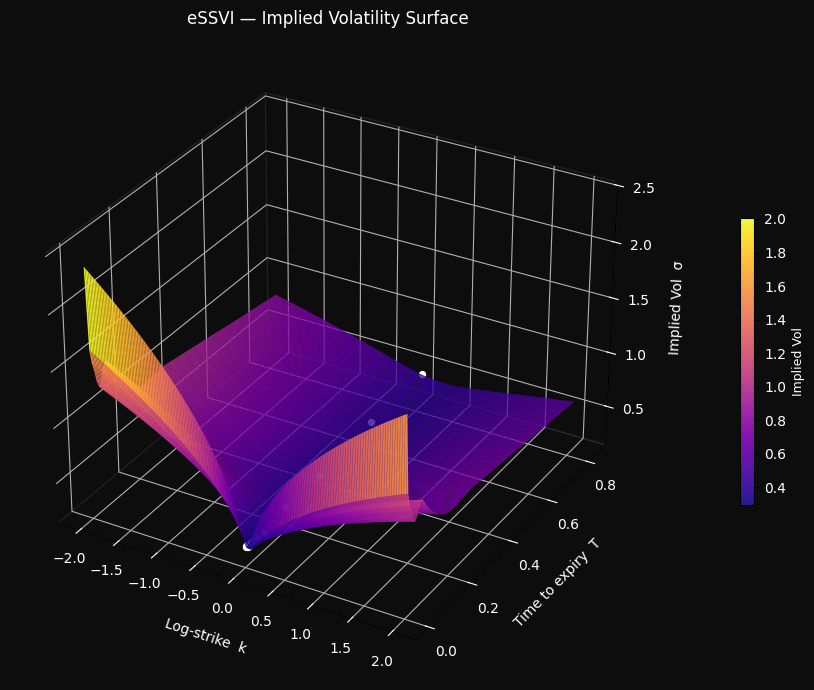

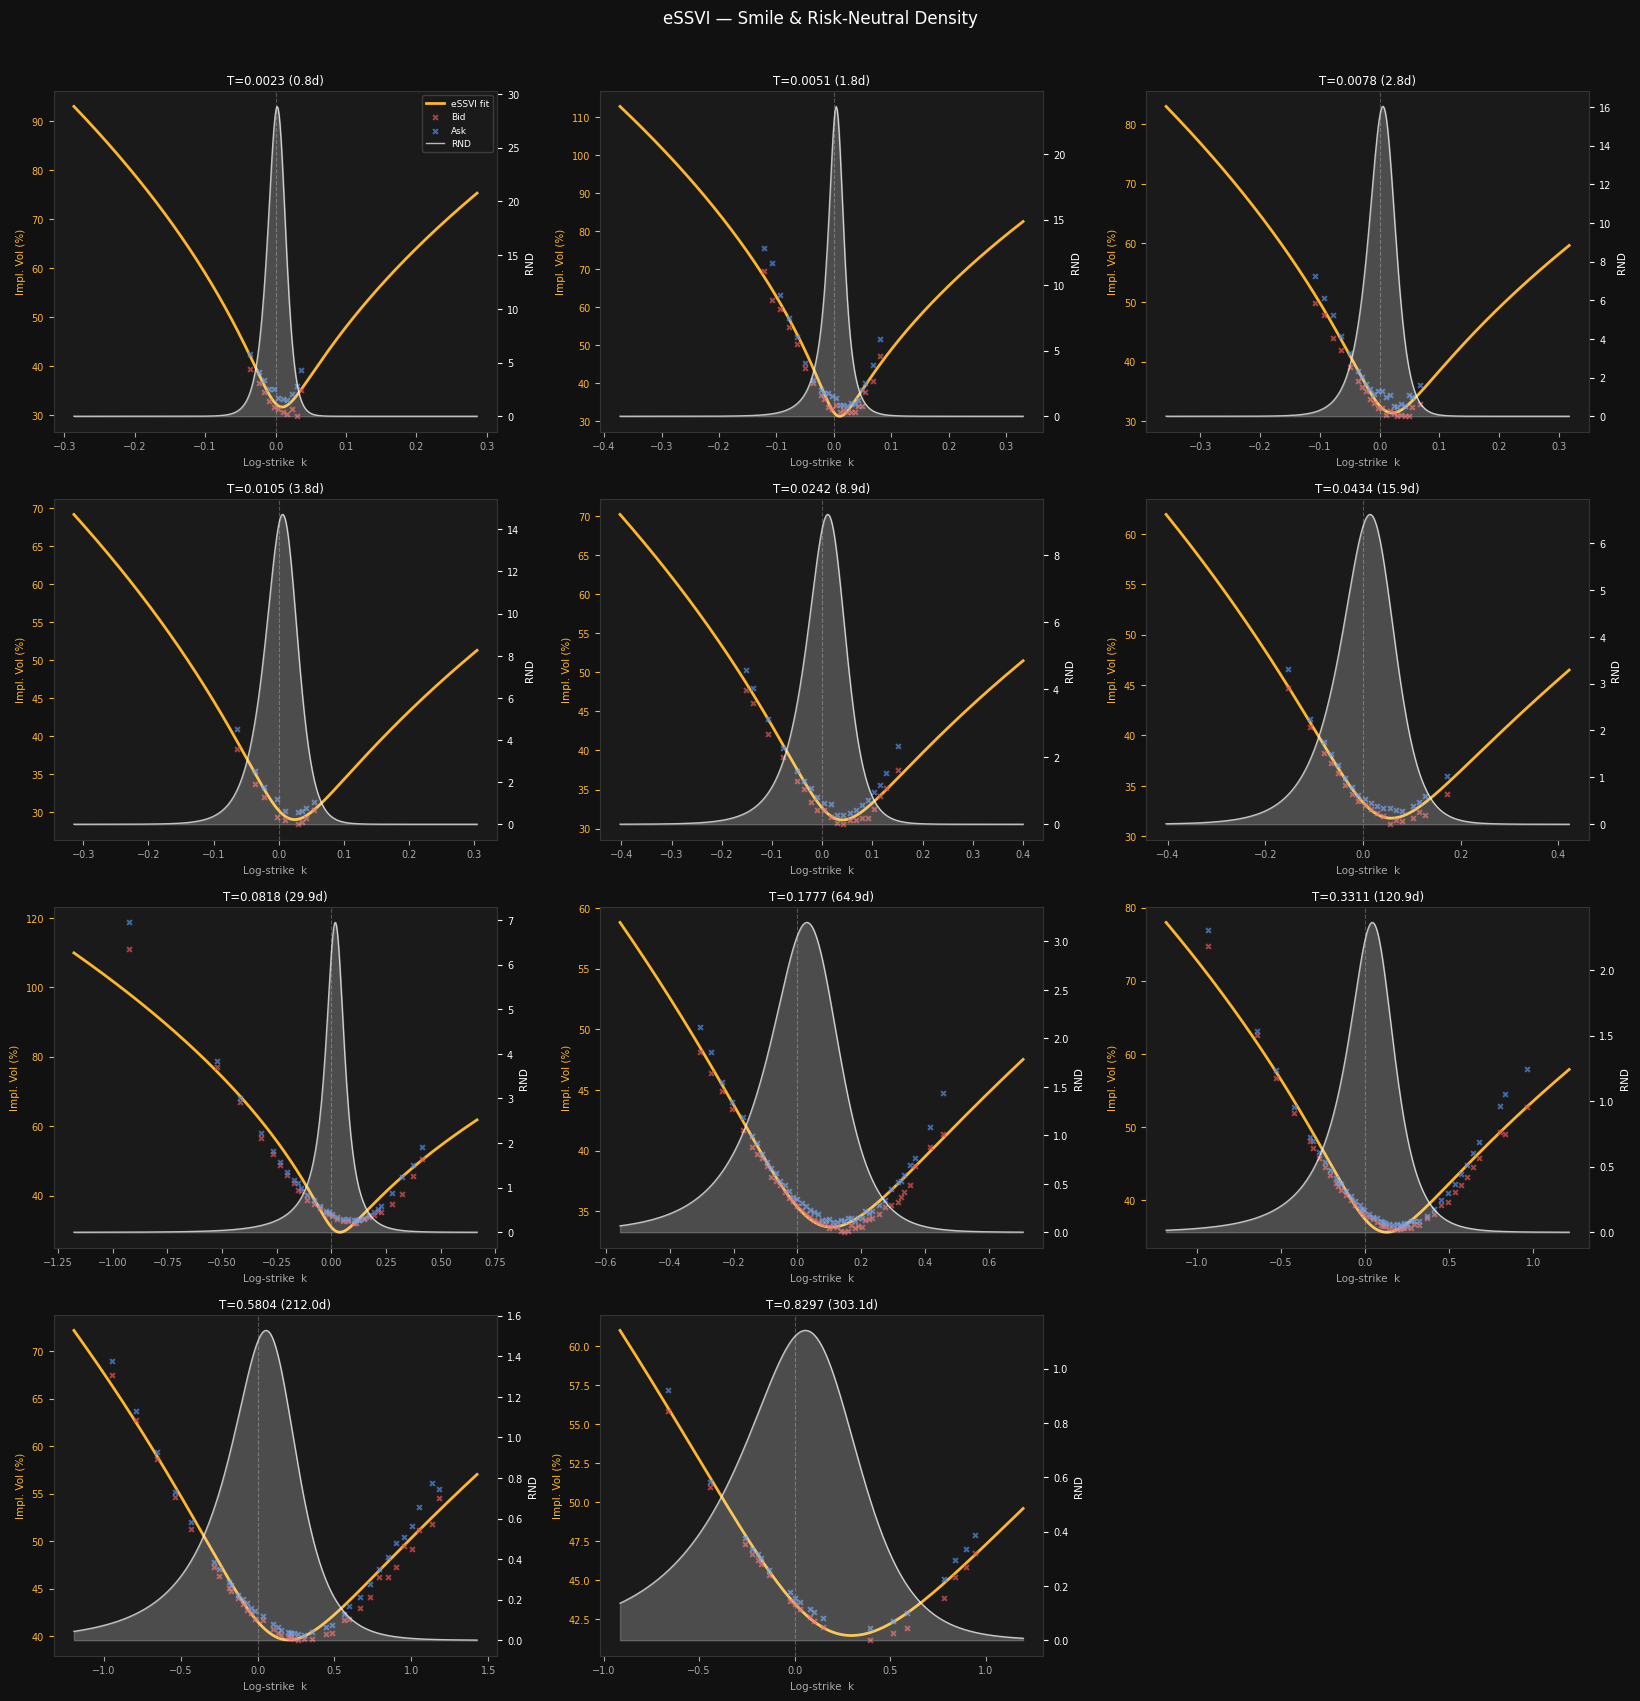

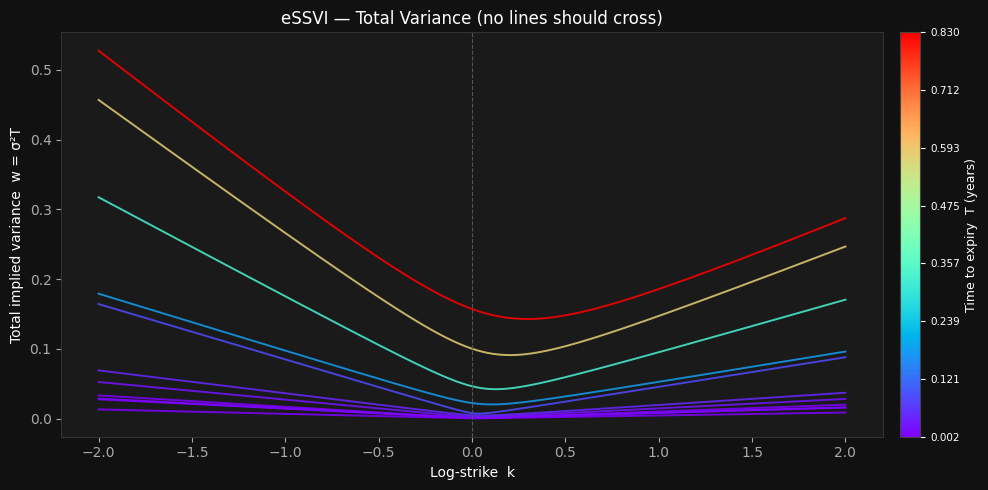

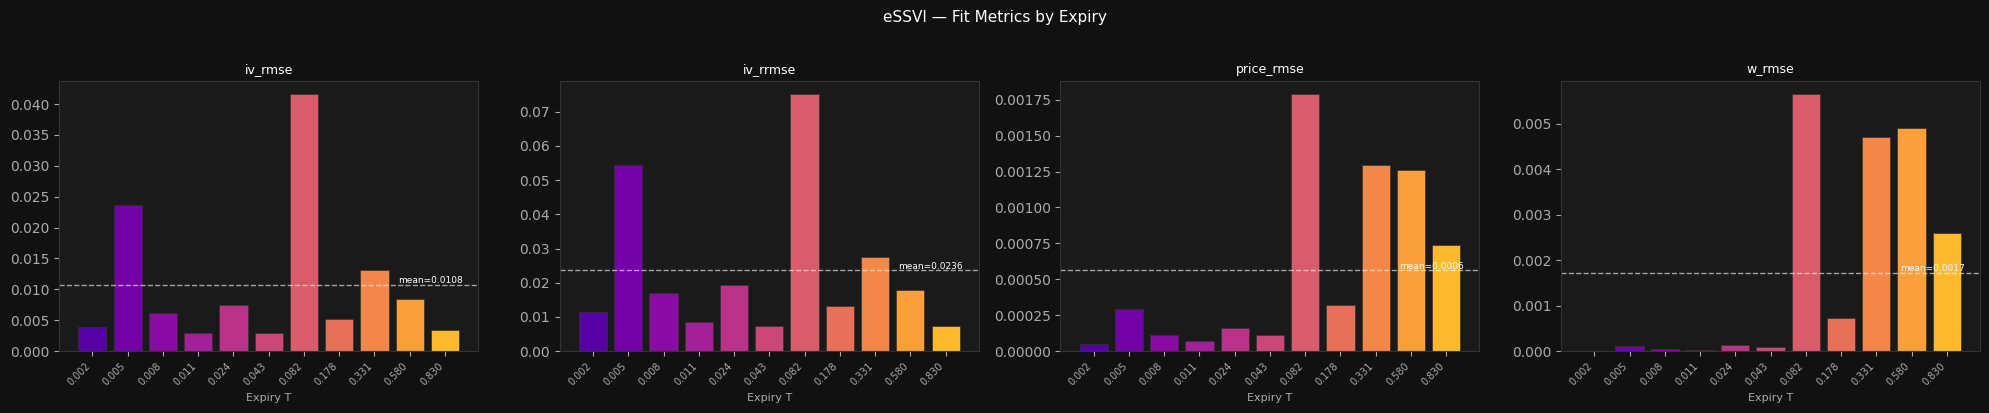

In [5]:
import pickle
with open('/Users/macbookair/Internship Natixis/calibration_results/essvi_btc_2026_05_27.pkl','rb') as f:
    r_essvi = pickle.load(f)

plot_all(r_essvi, df=snapshot)
plt.show()


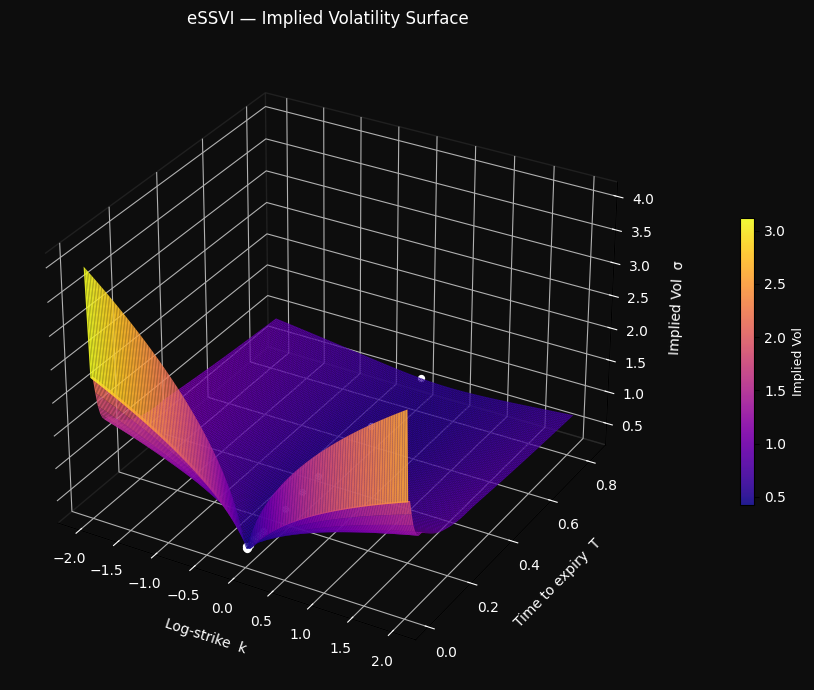

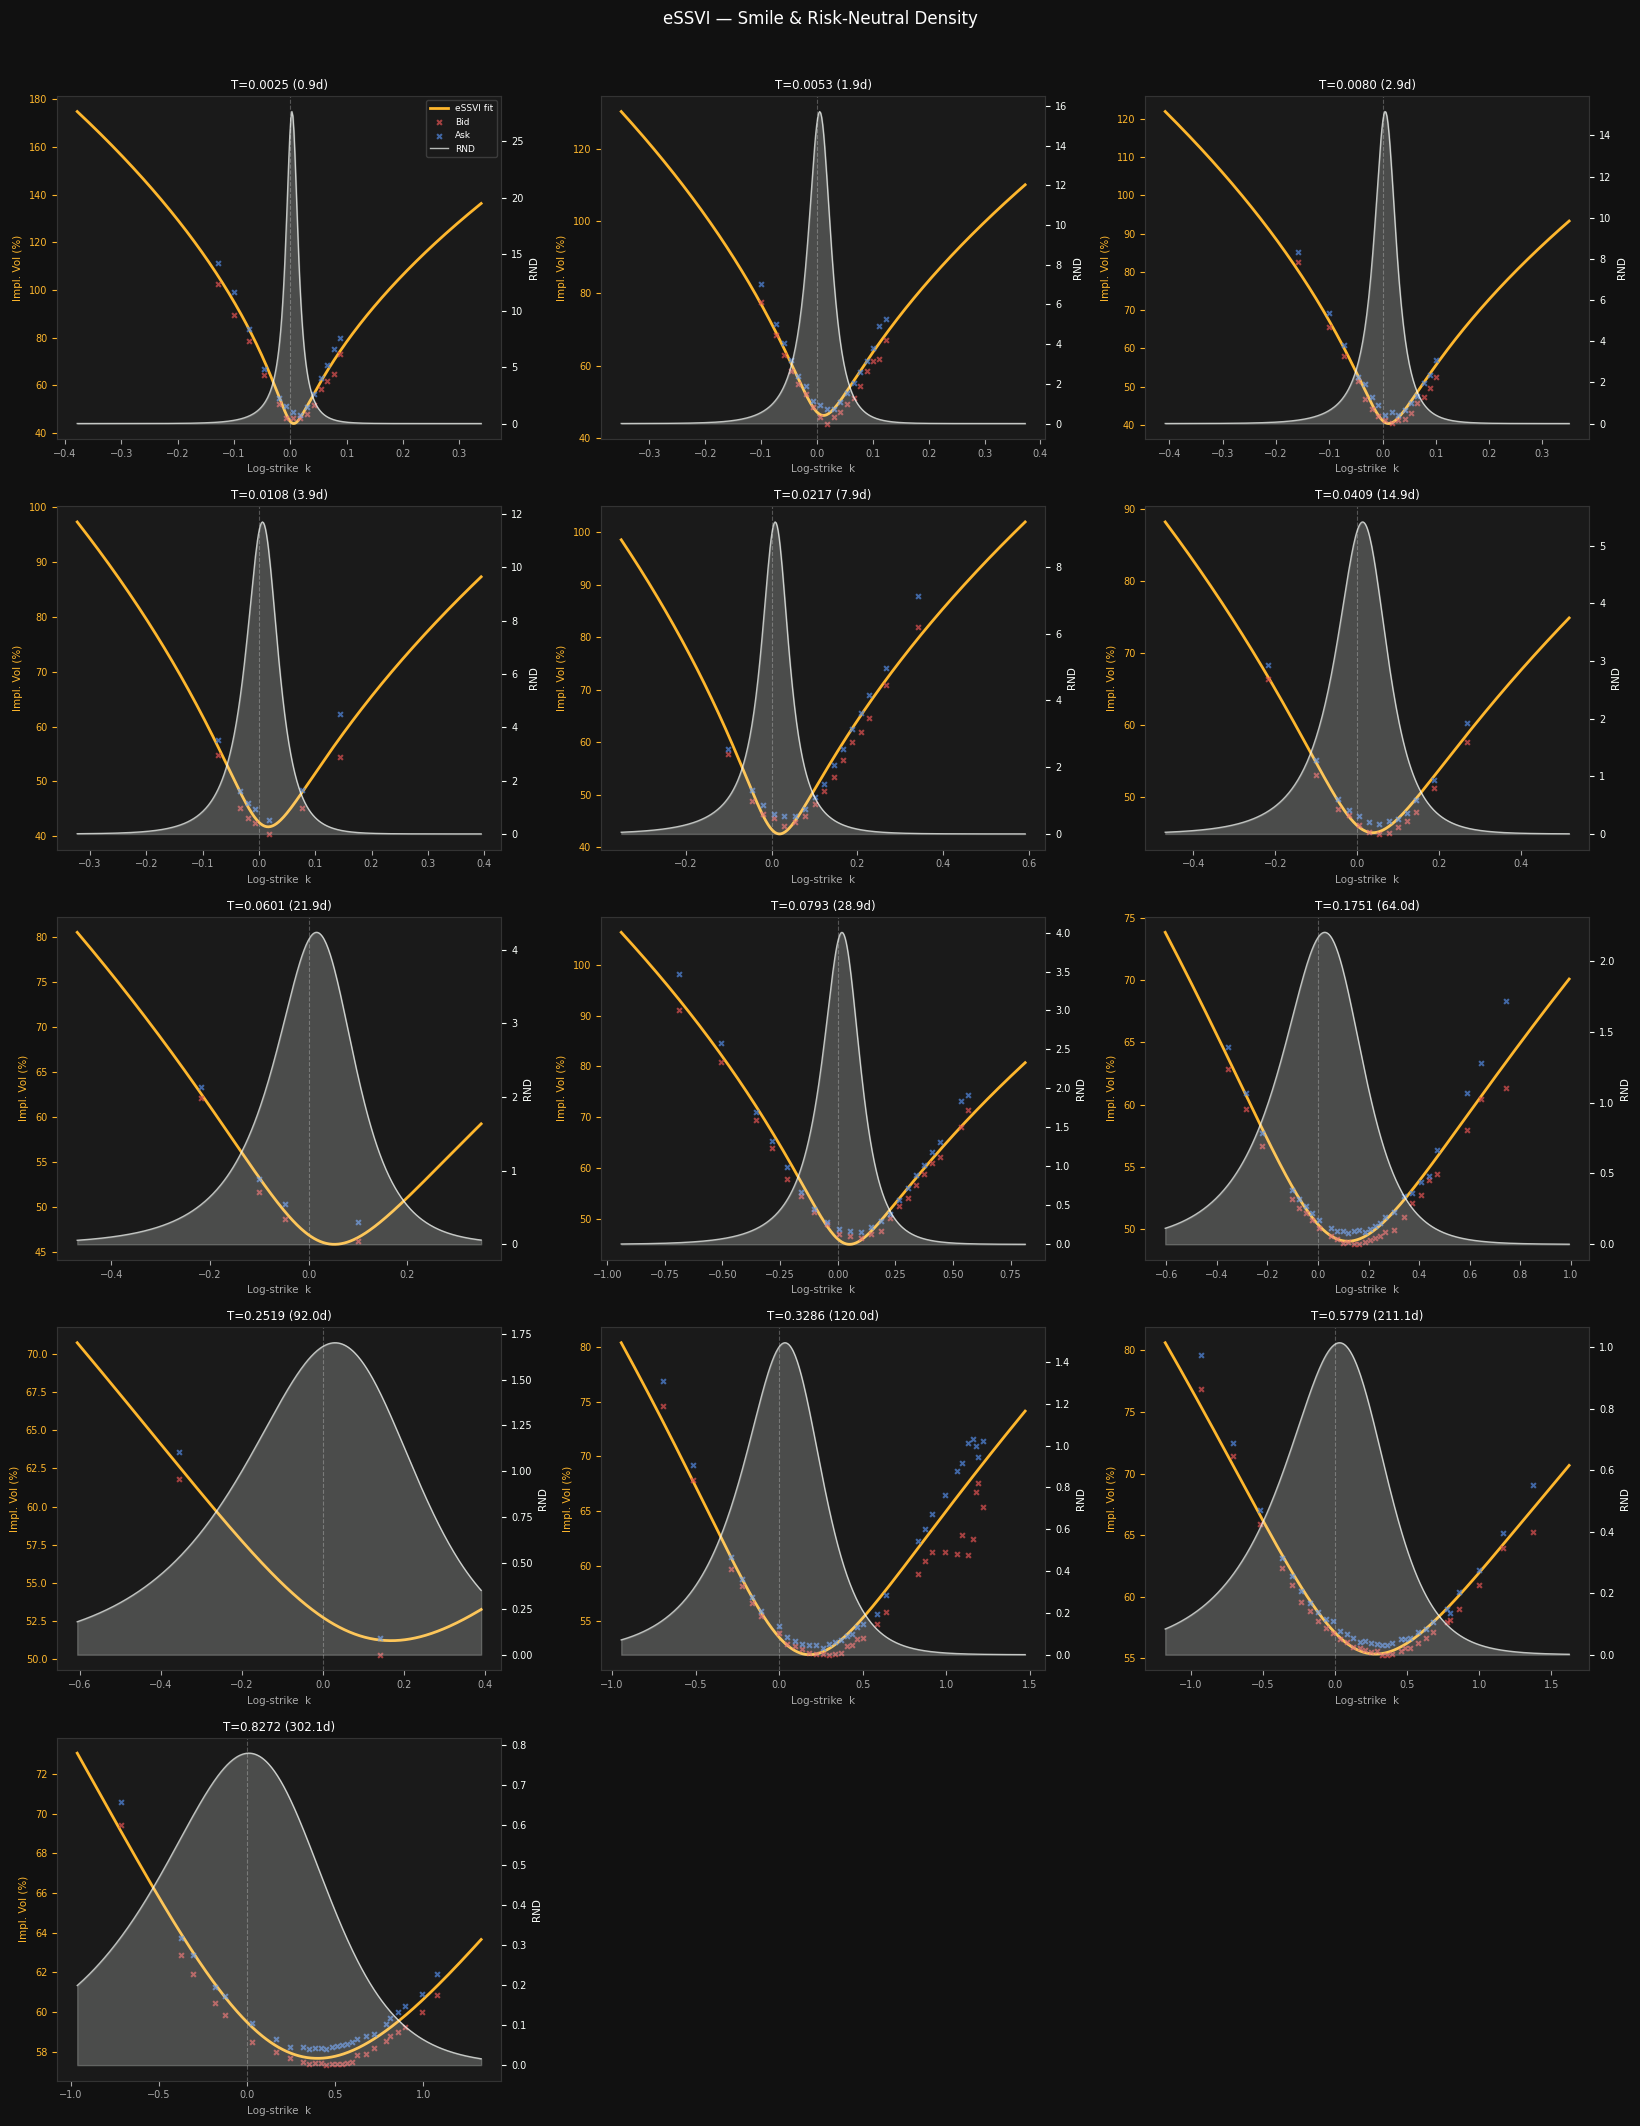

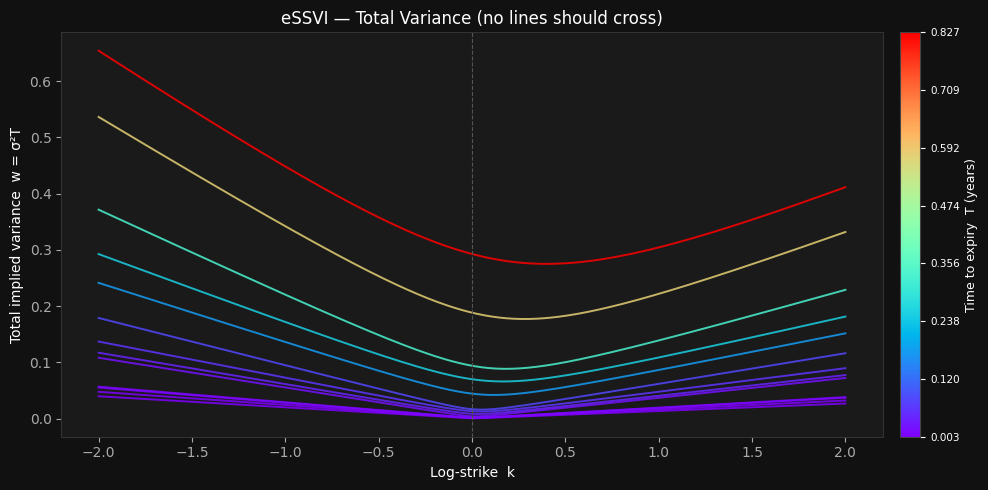

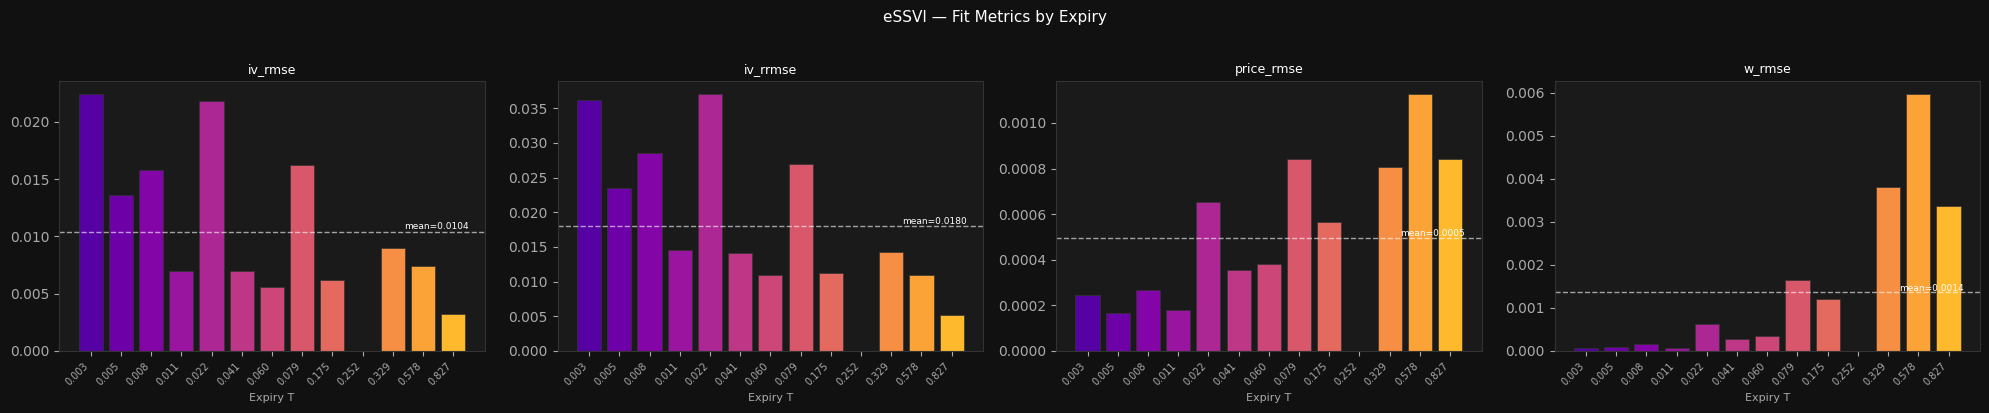

In [3]:
import pickle
with open('/Users/macbookair/Internship Natixis/calibration_results/essvi_calibration_results_v2.pkl','rb') as f:
    r_essvi = pickle.load(f)

plot_all(r_essvi, df=snapshot)
plt.show()


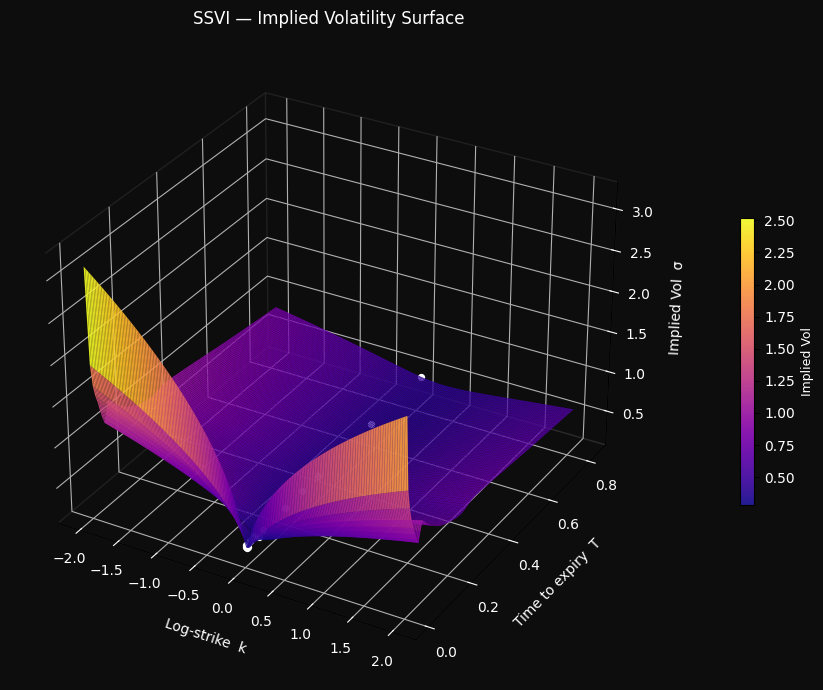

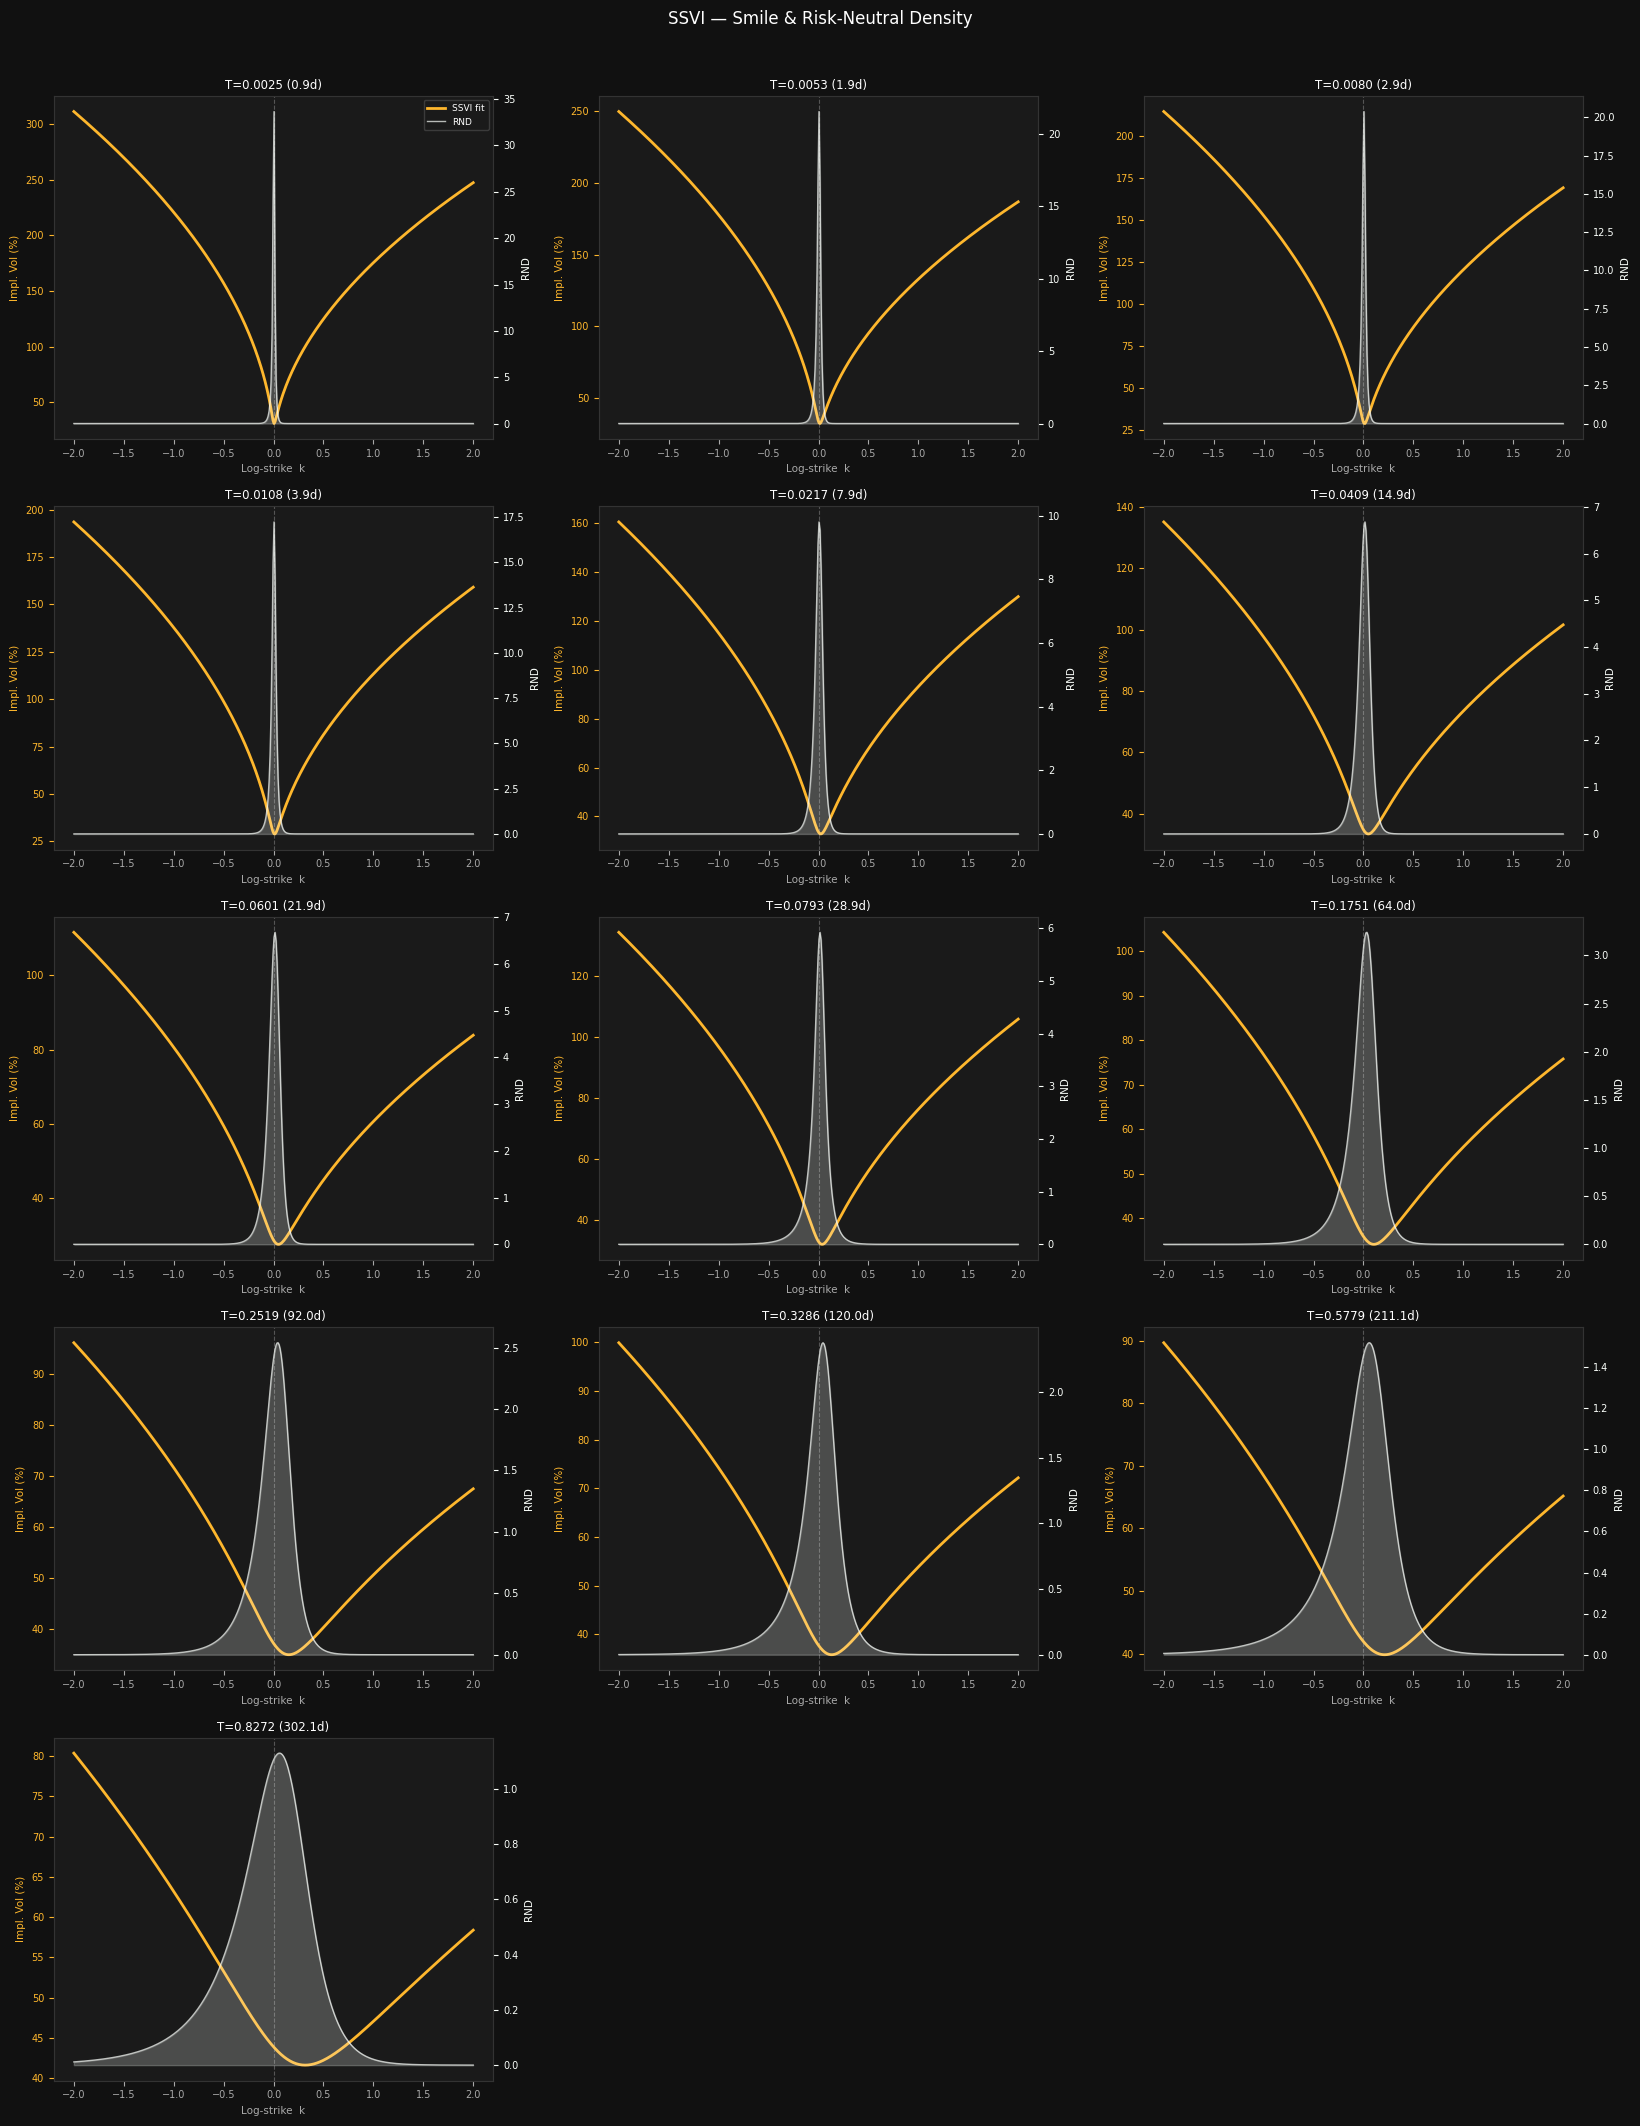

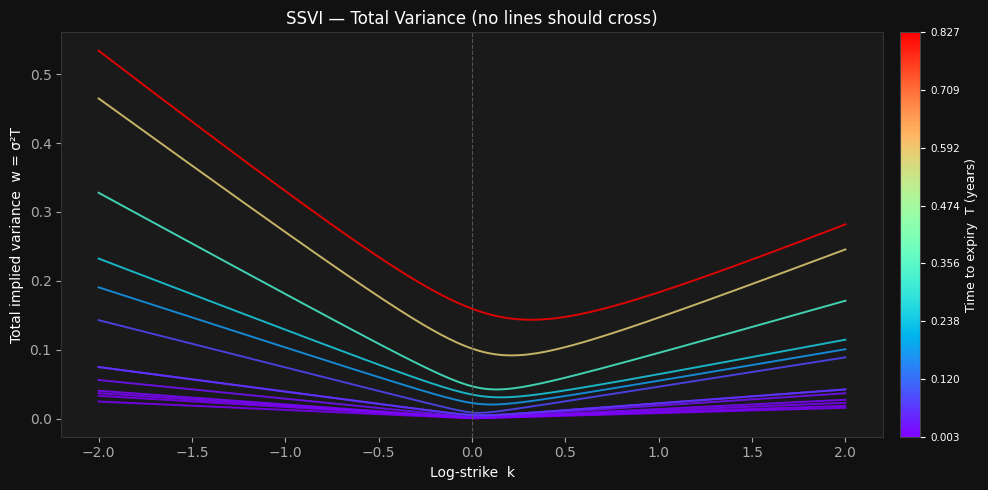

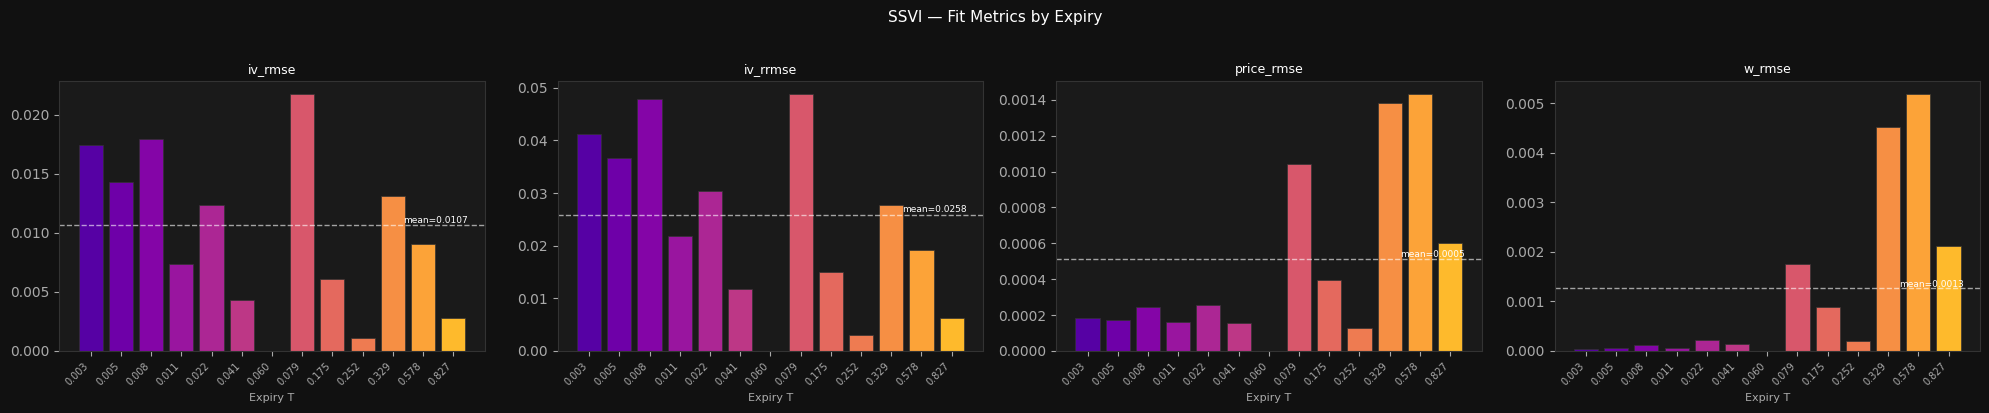

In [6]:
import pickle
with open('/Users/macbookair/Internship Natixis/calibration_results/ssvi_calibration_results.pkl','rb') as f:
    r_ssvi = pickle.load(f)

plot_all(r_ssvi, df=snapshot)
plt.show()


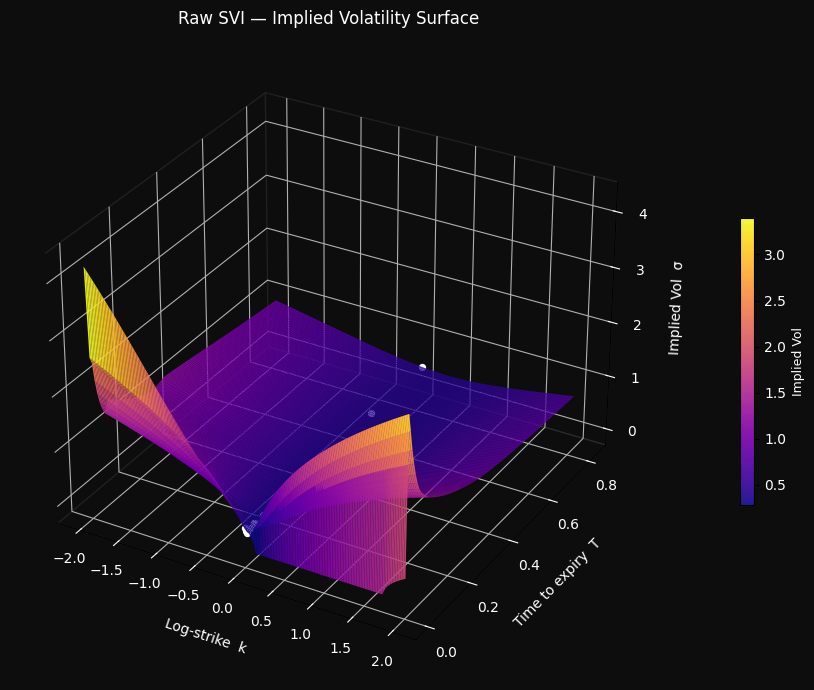

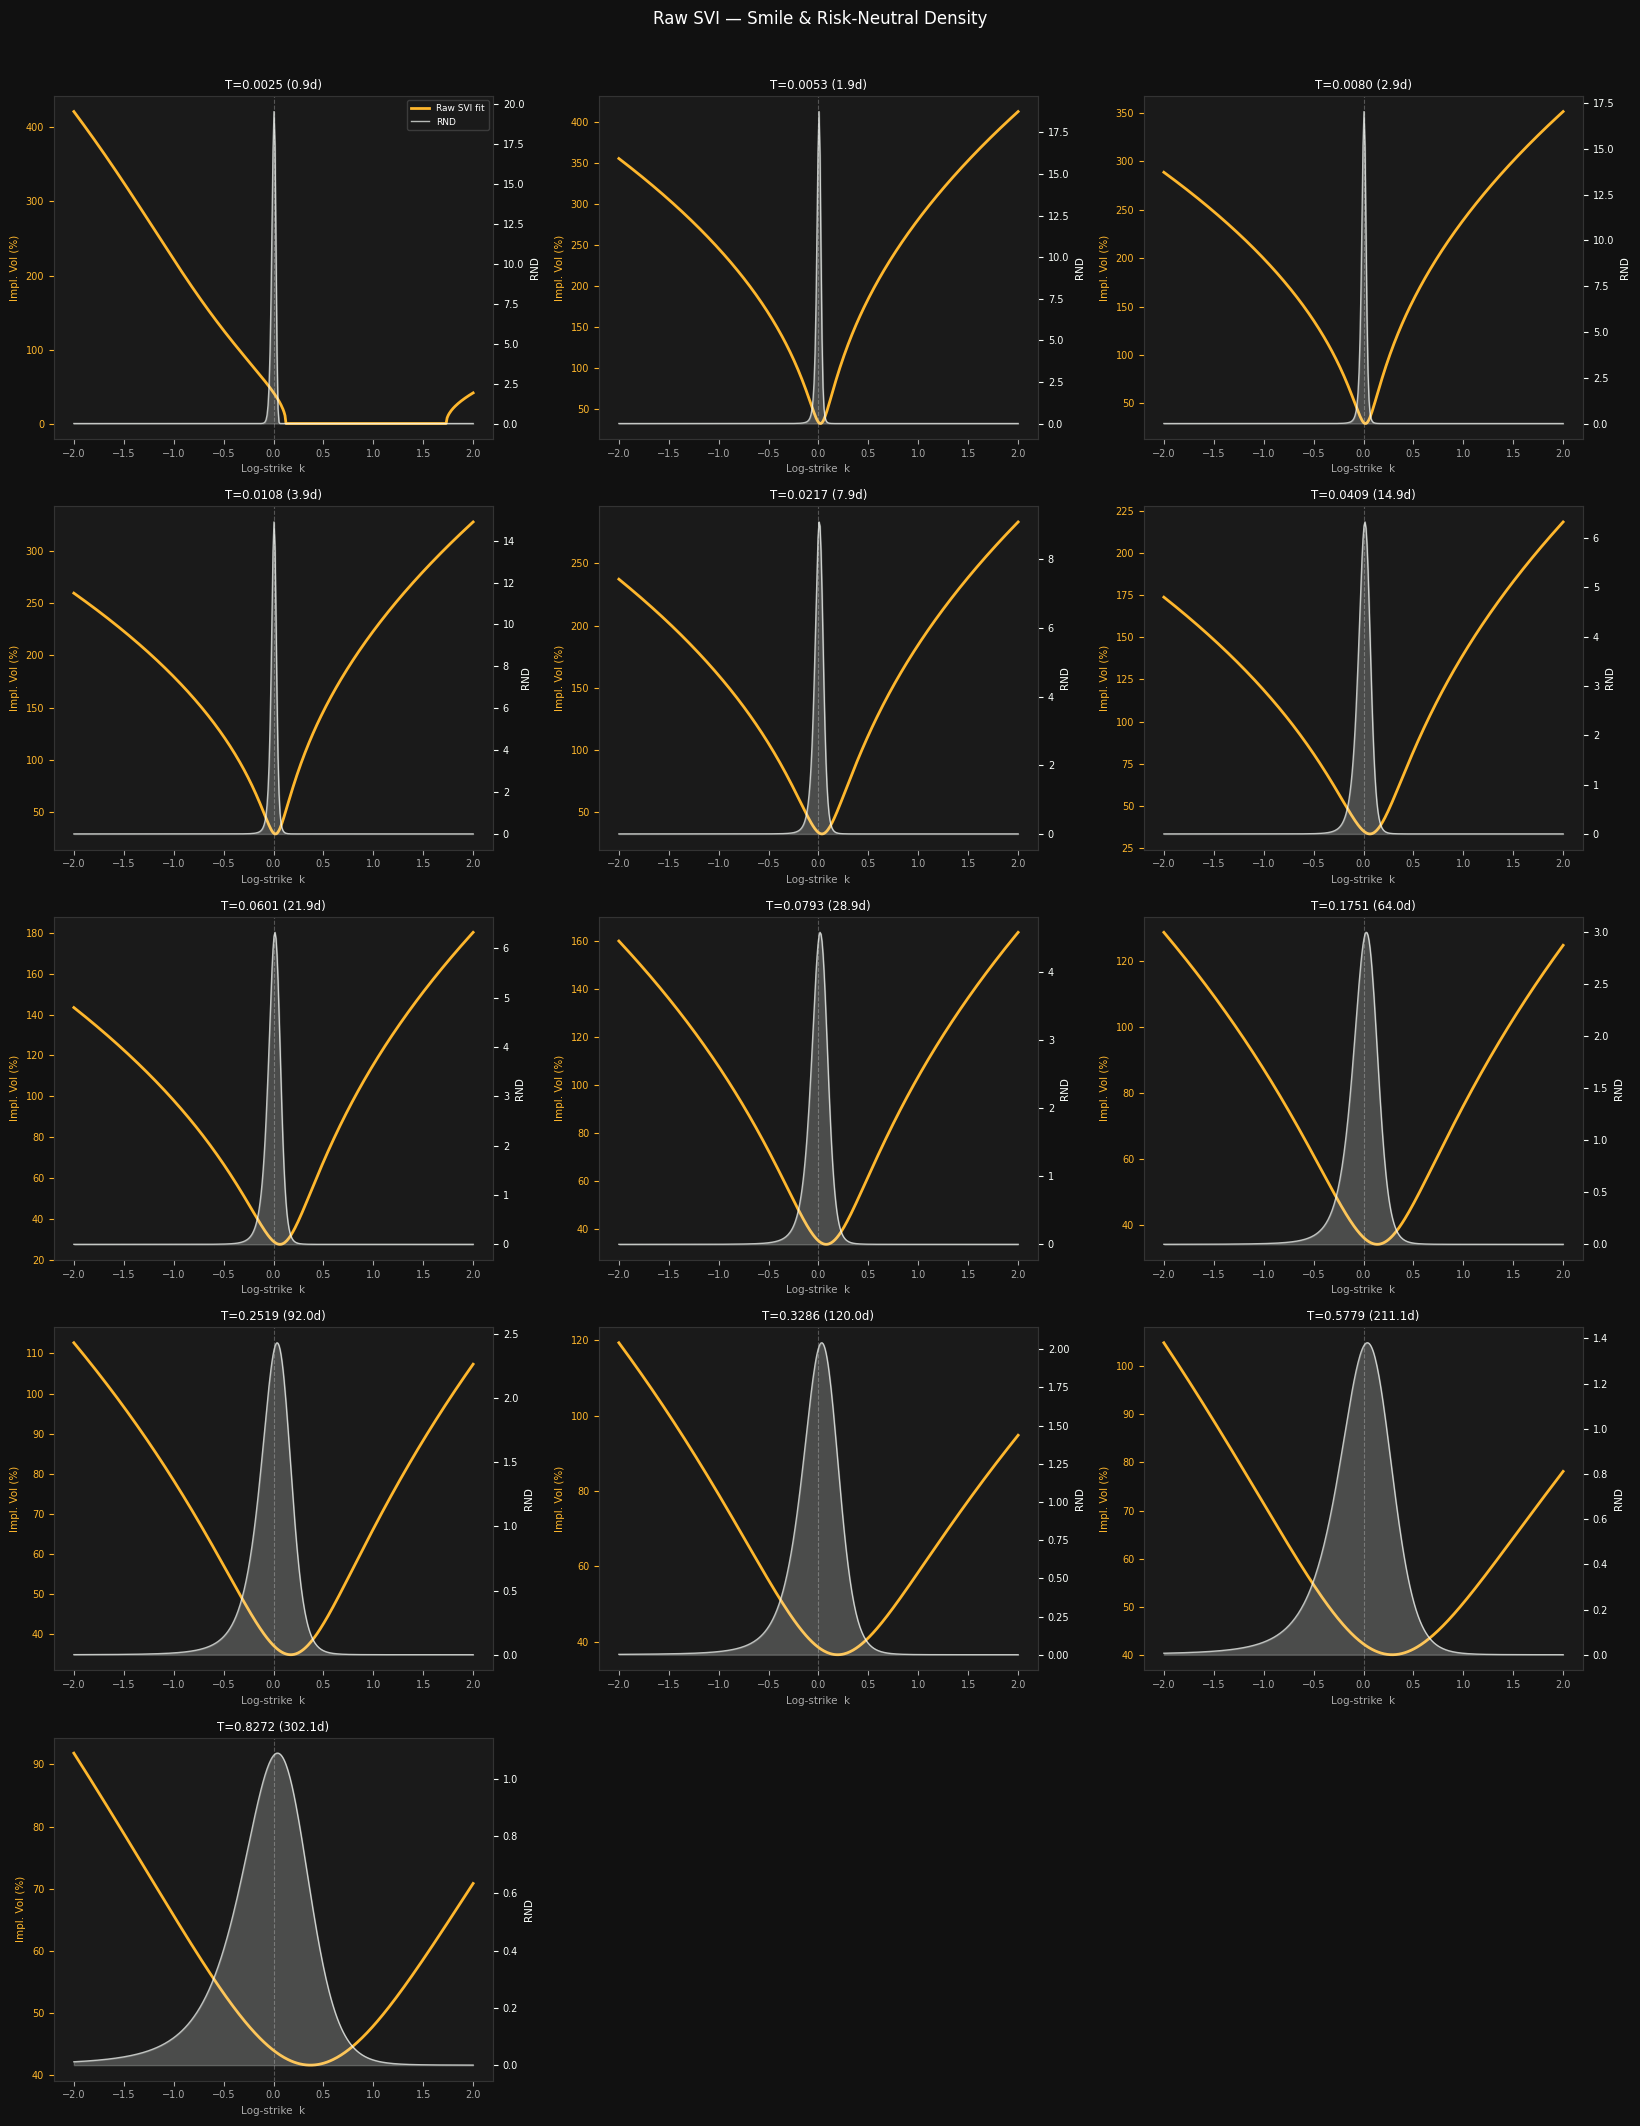

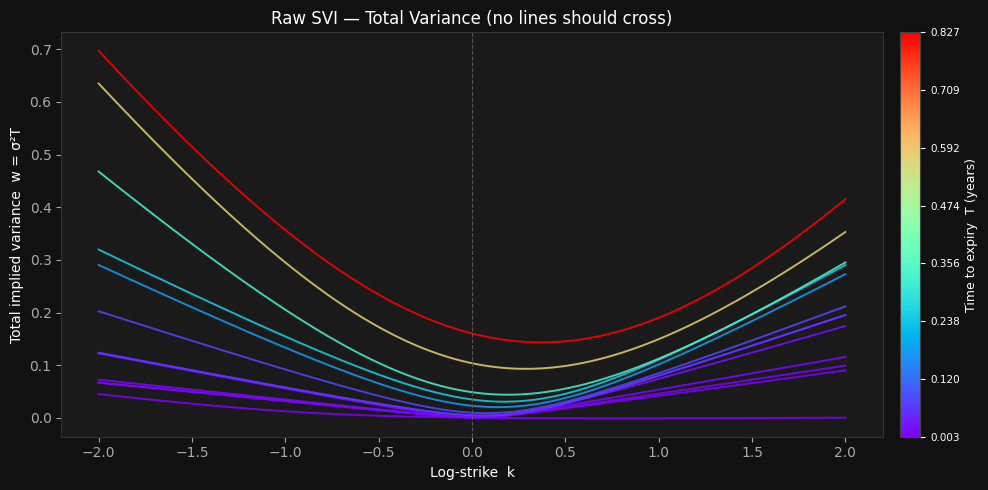

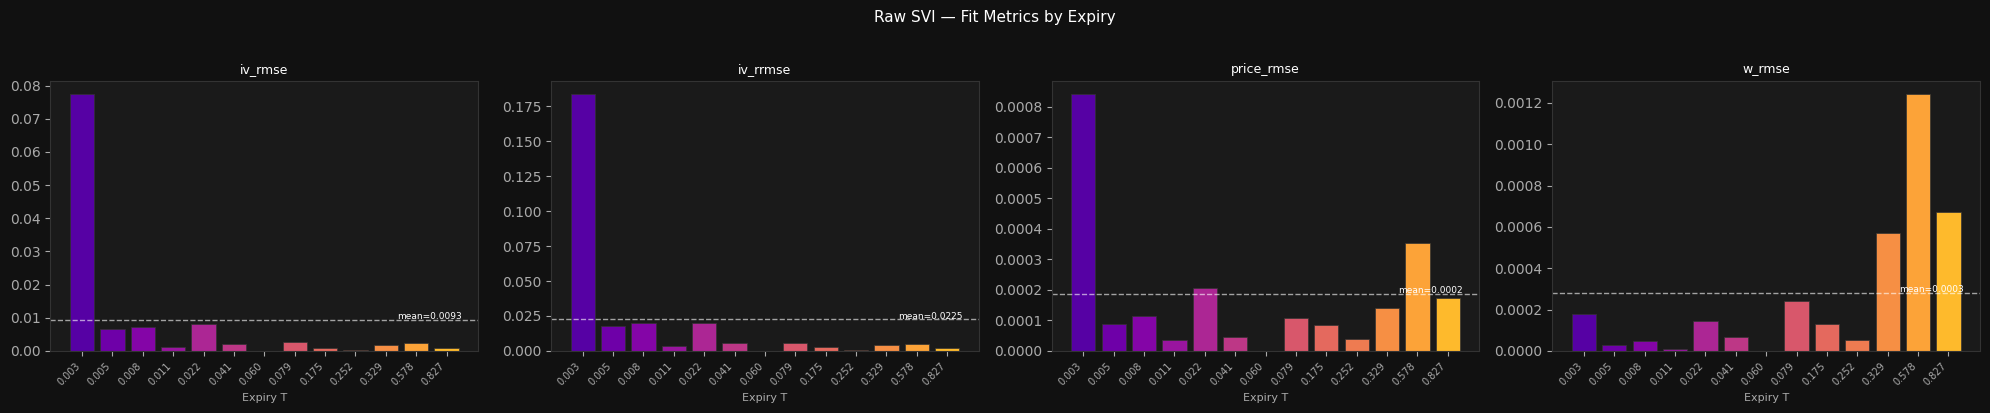

In [7]:

with open('/Users/macbookair/Internship Natixis/calibration_results/svi_calibration_results.pkl','rb') as f:
    r_svi = pickle.load(f)

plot_all(r_svi, df=snapshot)
plt.show()


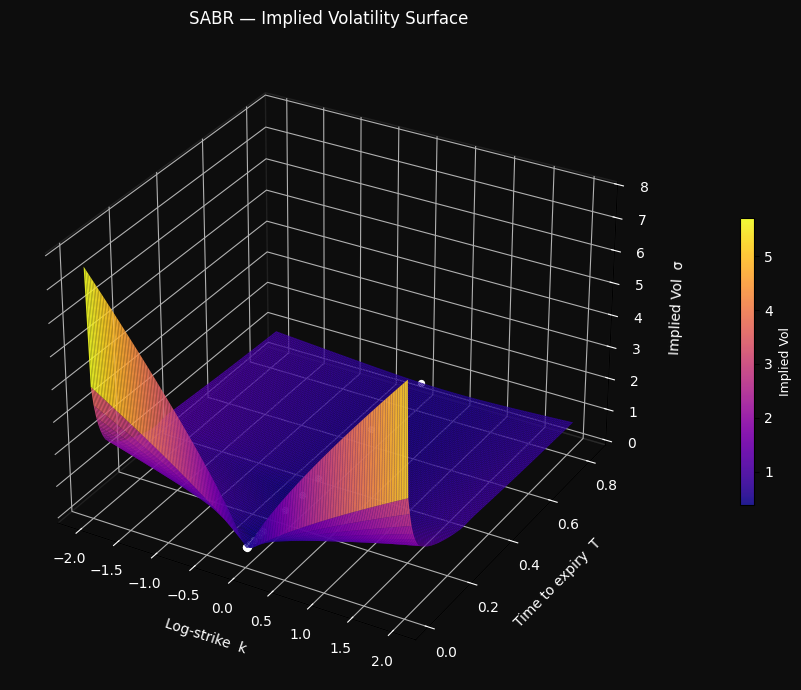

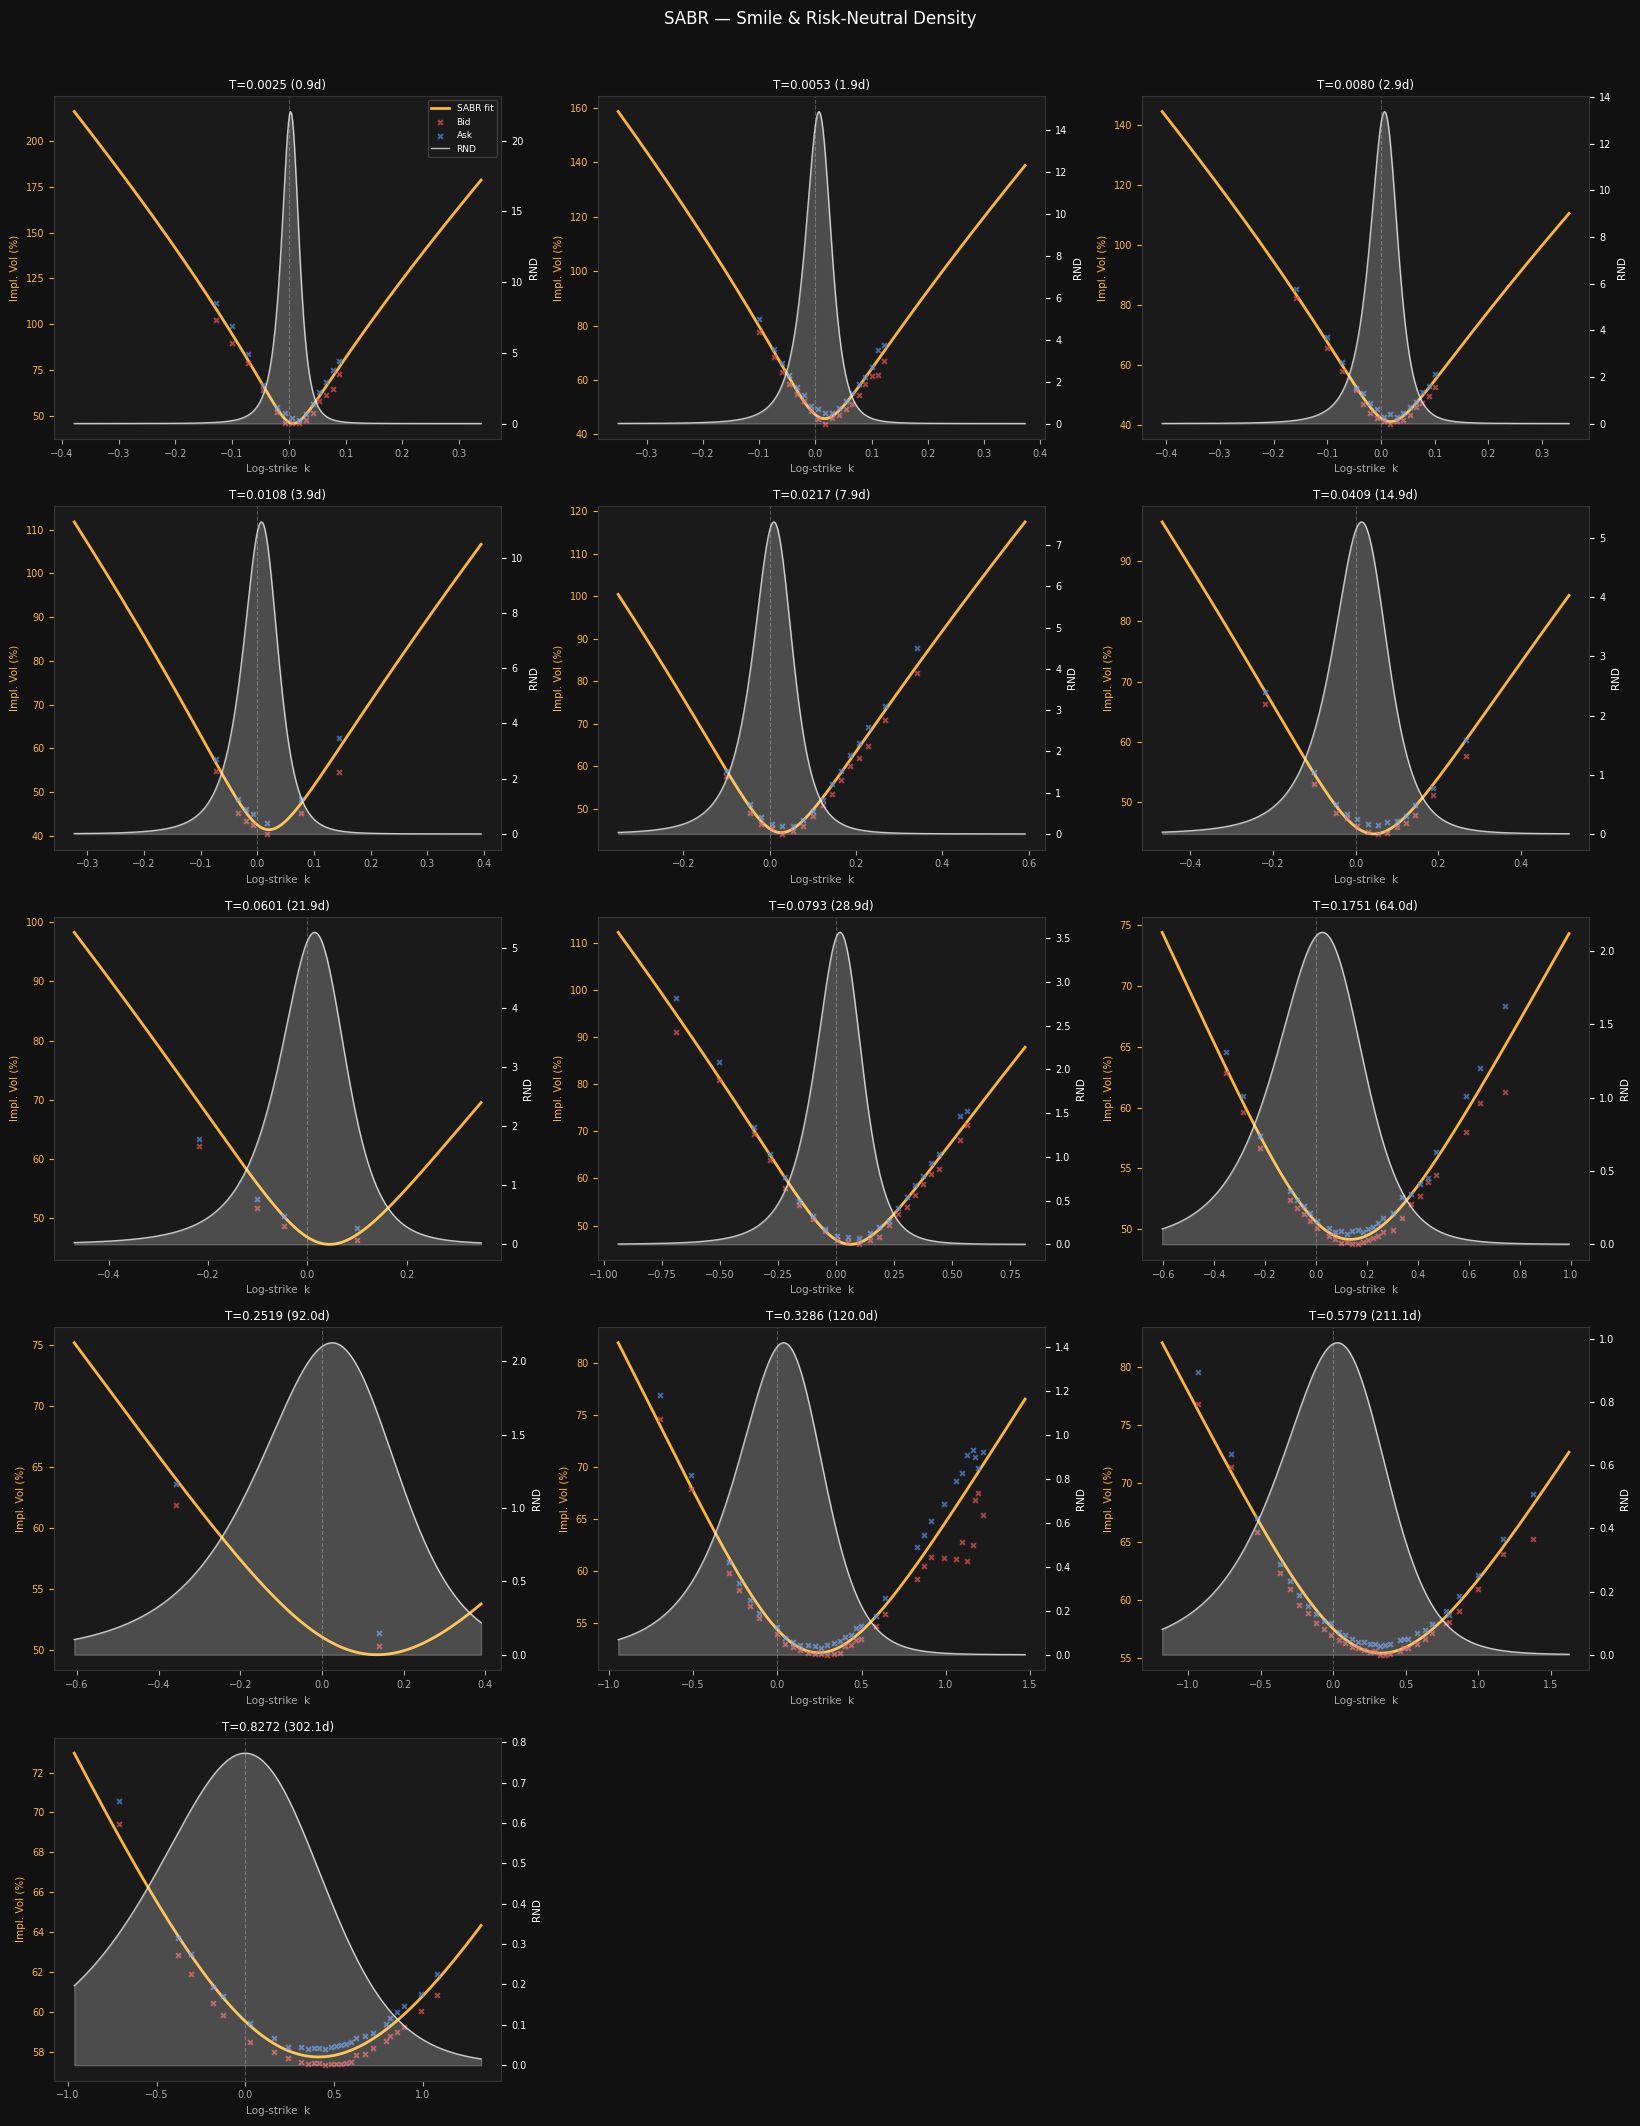

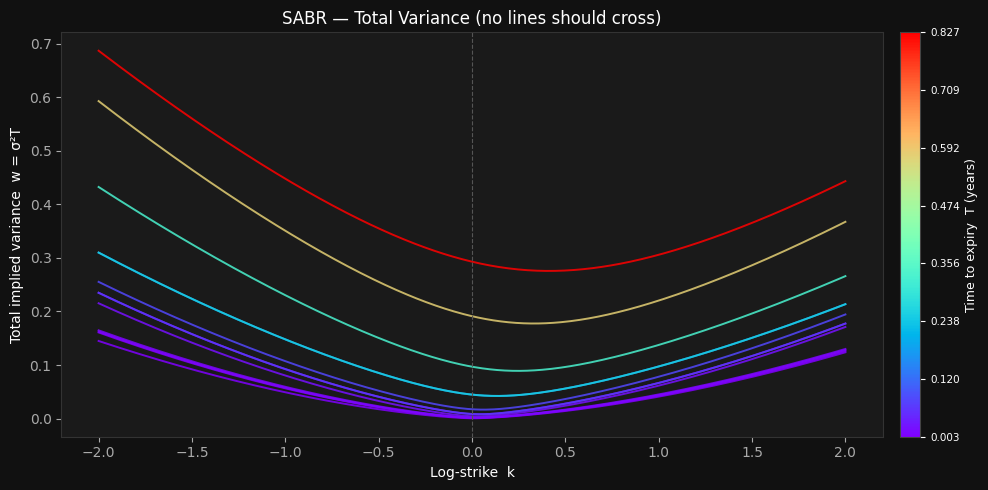

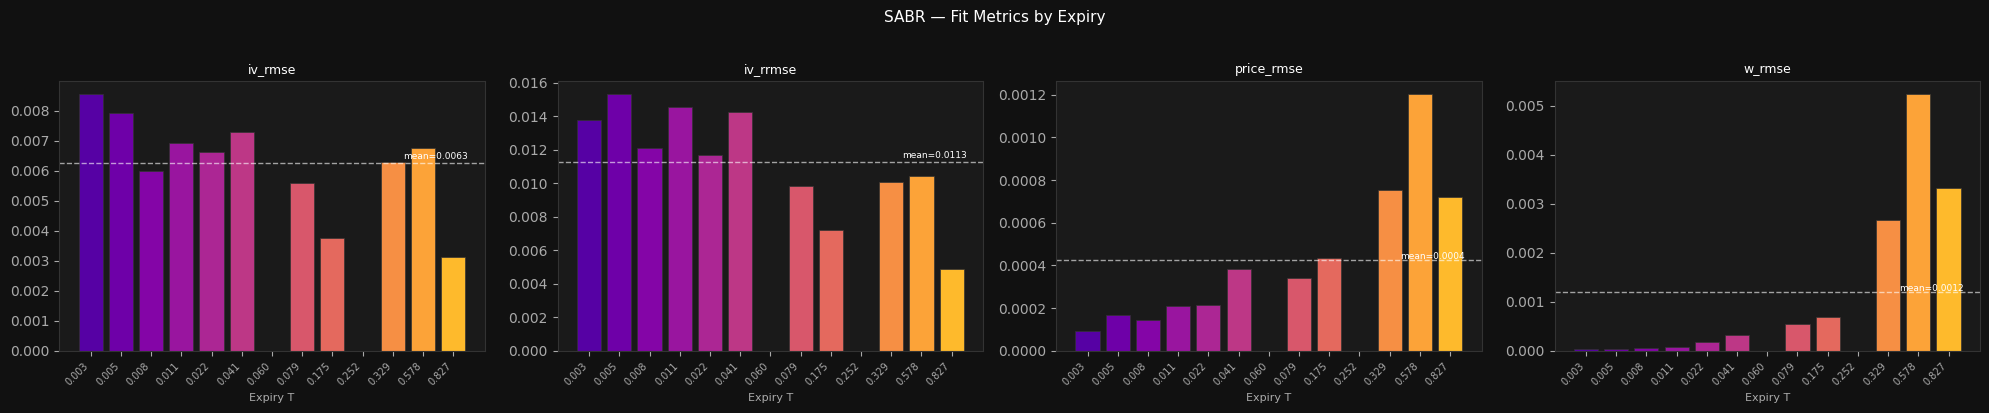

In [8]:

with open('/Users/macbookair/Internship Natixis/calibration_results/sabr_calibration_results.pkl','rb') as f:
    r_sabr = pickle.load(f)

plot_all(r_sabr, df=snapshot)
plt.show()


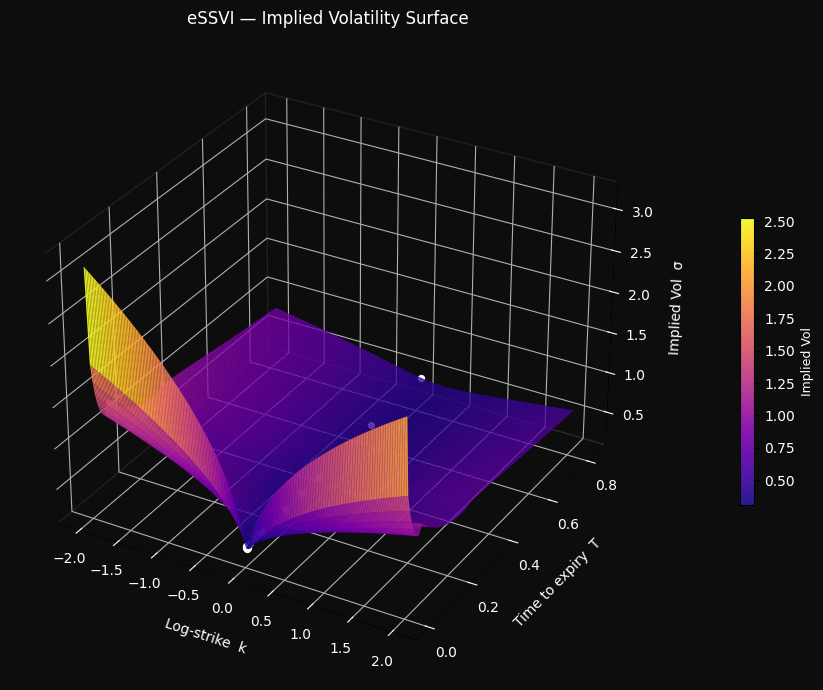

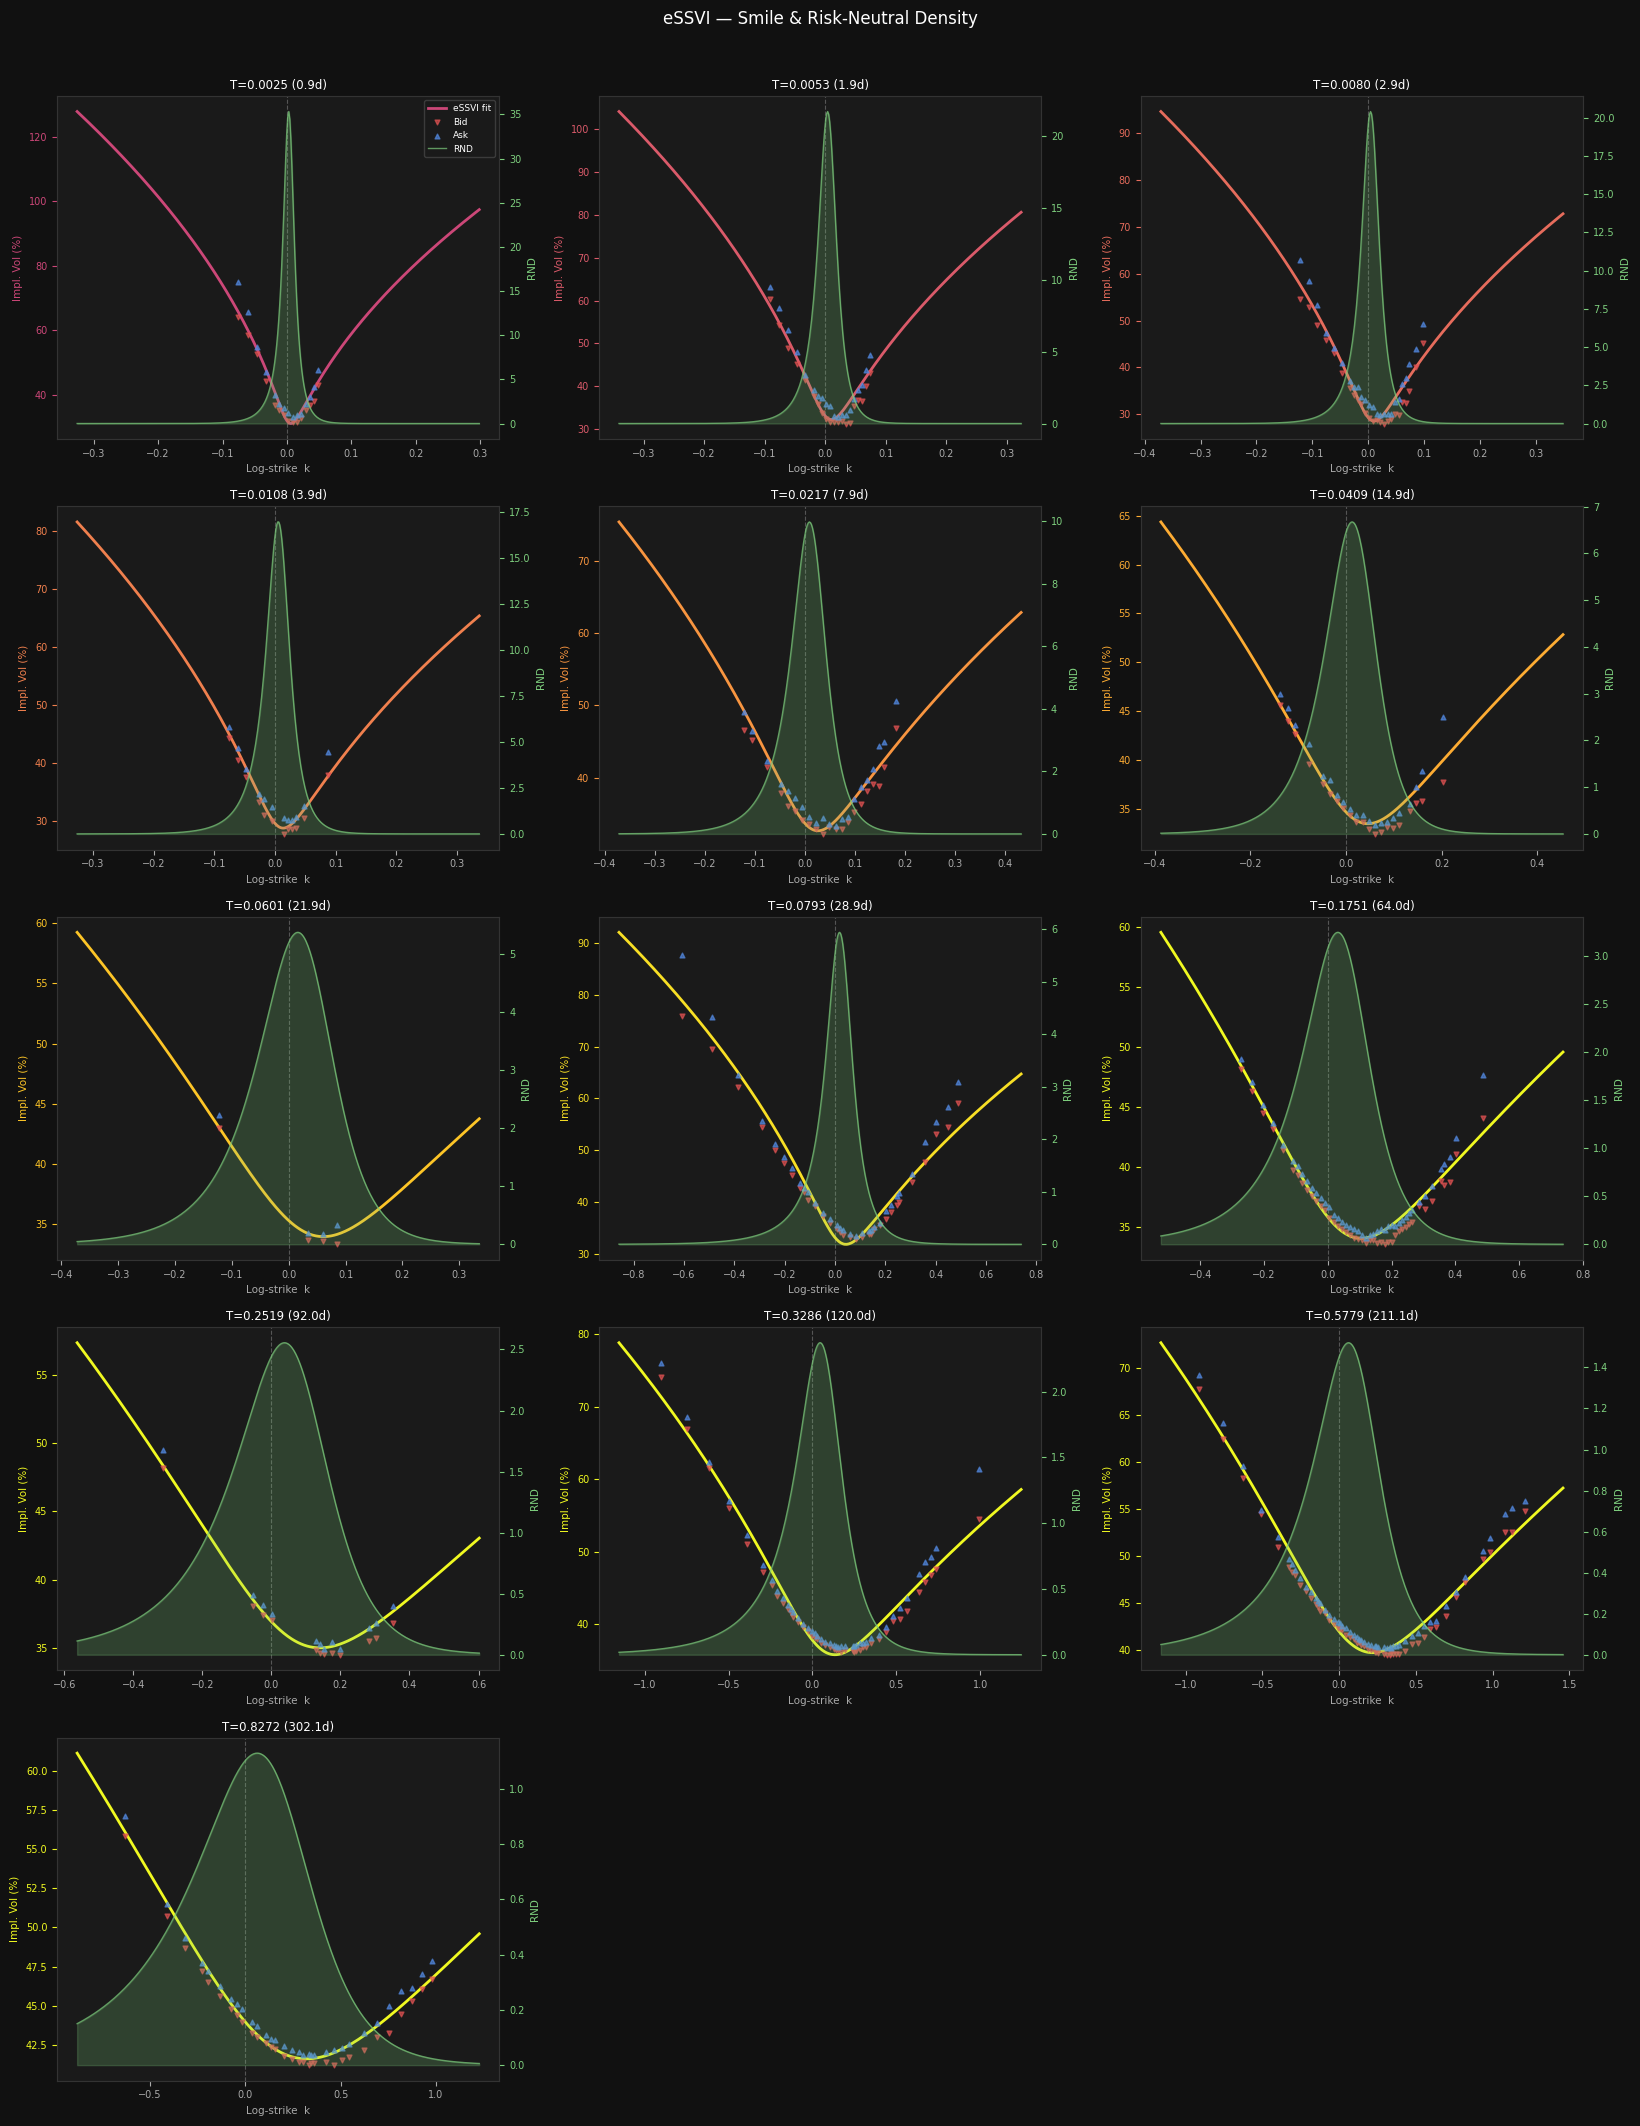

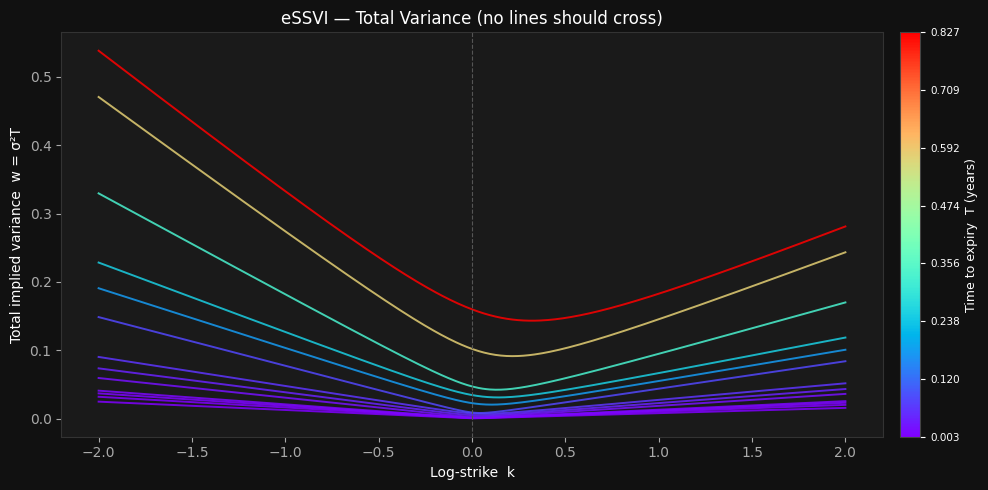

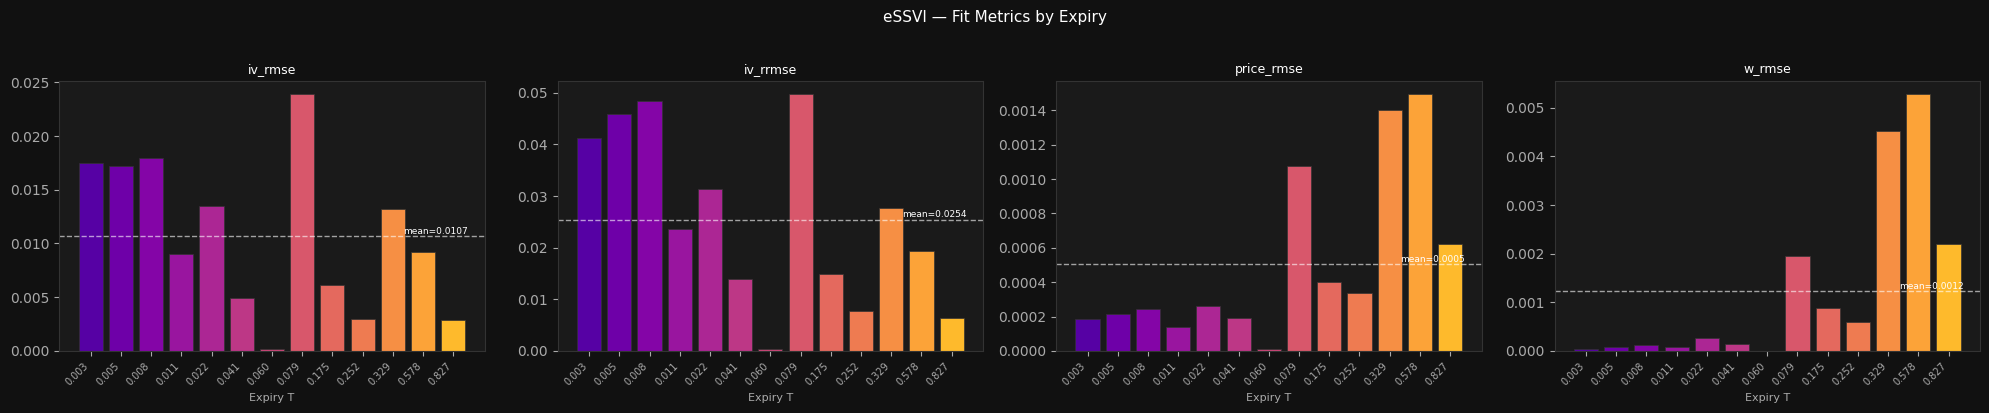

In [4]:
# from objectives import OBJECTIVES
# import pickle
# df_full = pd.read_parquet('/Users/macbookair/Internship Natixis/data/min_options_data.parquet')
# df_t0 = df_full[df_full.file_timestamp == df_full.file_timestamp.unique()[-1]].copy()
# df_vol = df_t0[df_t0.volume>0]
# datasets = {'full':df_t0,'filtered':df_vol}

# for df_name, df in datasets.items():
#     for obj_name in OBJECTIVES.keys():
#         for model_name in ['svi','ssvi','sabr']:
#             model = get_model(model_name)
#             obj = get_objective(obj_name)

#             result = calibrate_snapshot(
#                 df, 
#                 model=model,
#                 objective=obj,
#                 verbose=False
#             )
#             filename = f'result_{model_name}_{obj_name}_{df_name}.pkl'
#             with open(filename,'wb') as f:
#                 pickle.dump(result,f)
#             print('saved',filename)

By excluding  all options that have not been traded in the last 24 hours, 

Raw
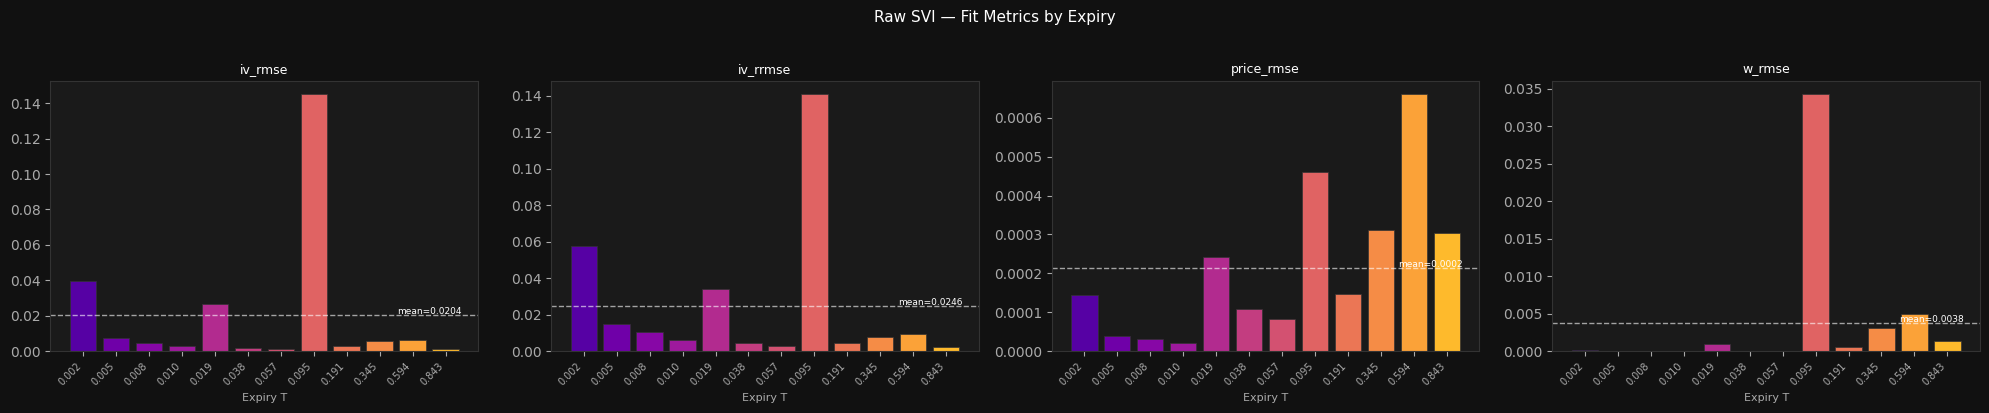

Volume-Filtered : 
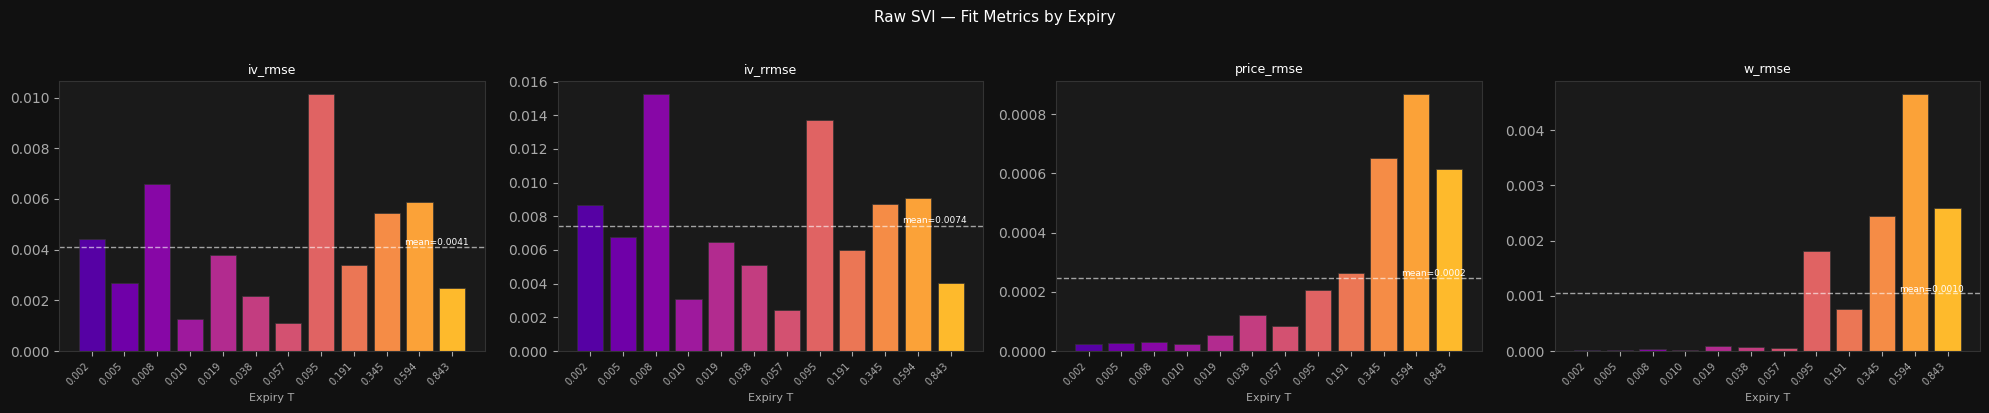

IV RMSE : Reduced by 80% \
IV RRMSE : Reduced by 70% \
Price RMSE: no change -> makes sense because iv improving by 80% on a few percent is extremely small : vega isn't large enough generally to warrant a large change \
W Rmse : Improved by 75%

In [12]:
snapshot.loc[snapshot.spread_iv.idxmax(),:]

bid_price                                0.0001
ask_price                                0.0003
open_interest                           18685.0
mark_price                             0.000201
creation_timestamp_x              1779961373133
volume                                   1604.0
mark_iv                                  0.7089
underlying_price                         1989.9
underlying_index                    ETH-29MAY26
estimated_delivery_price                1990.39
mid_price                                0.0002
price_index                             1990.39
expiration_timestamp        2026-05-29 08:00:00
strike                                     2150
settlement_period                           NaN
option_type                                   C
instrument_id                ETH-29MAY26-2150-C
expiration_timestamp_ms         1780041600000.0
file_timestamp                 2026-05-28 09:42
t                                      0.002544
k                                      0

In [25]:

plt.cm.plasma(np.linspace(0.5, 1.25, 12))

array([[0.798216, 0.280197, 0.469538, 1.      ],
       [0.856547, 0.356066, 0.410322, 1.      ],
       [0.907365, 0.434524, 0.35297 , 1.      ],
       [0.951344, 0.52285 , 0.292275, 1.      ],
       [0.980556, 0.613039, 0.234646, 1.      ],
       [0.994324, 0.716681, 0.177208, 1.      ],
       [0.986509, 0.822401, 0.143557, 1.      ],
       [0.951726, 0.941671, 0.152925, 1.      ],
       [0.940015, 0.975158, 0.131326, 1.      ],
       [0.940015, 0.975158, 0.131326, 1.      ],
       [0.940015, 0.975158, 0.131326, 1.      ],
       [0.940015, 0.975158, 0.131326, 1.      ]])

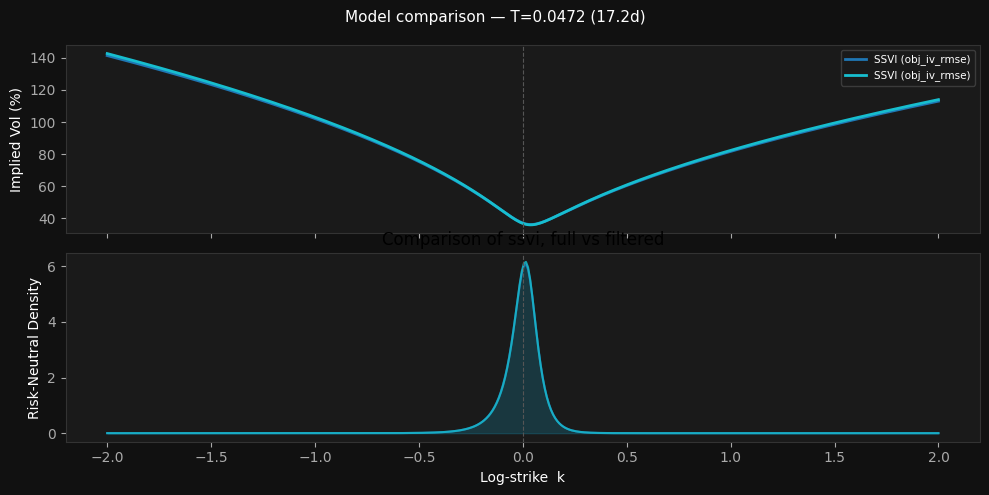

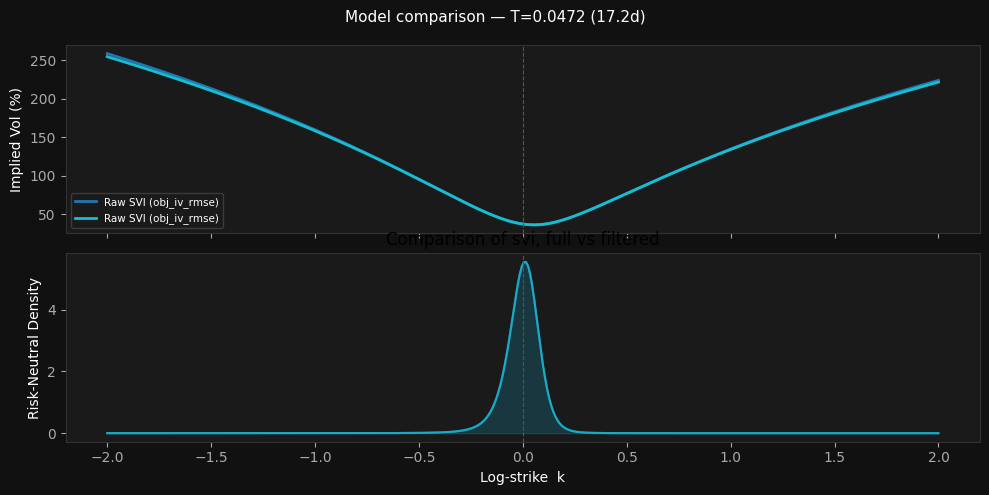

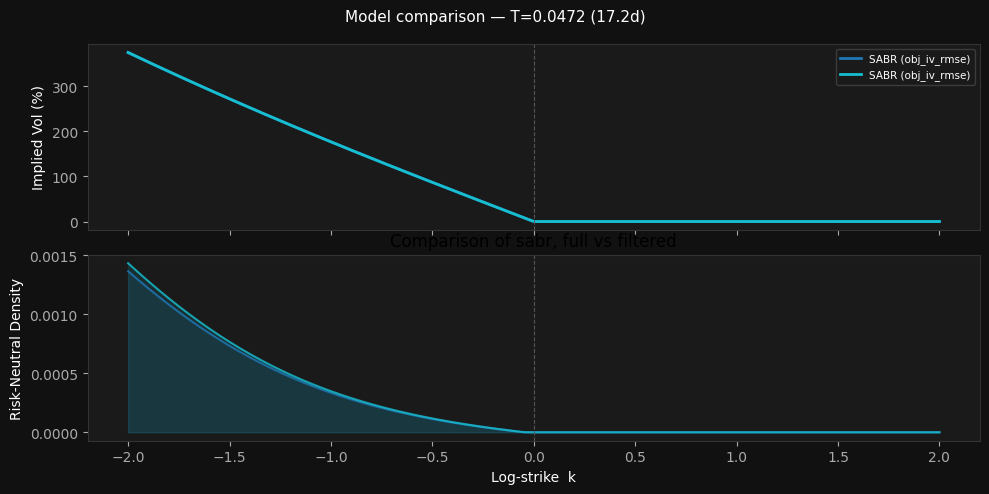

In [28]:
import pickle
snapshot = df[df.file_timestamp == df.file_timestamp.unique()[-1]].copy()
results_dict = {}
for model in ['ssvi','svi','sabr']:
    for folder in ['filtered','full']:
        with open(f'calibration_results/{folder}/result_{model}_iv_rmse_{folder}.pkl', 'rb') as f:
            results = pickle.load(f)
            results_dict[f'{folder}_{model}'] = results
    plot_compare([results_dict[f'filtered_{model}'],results_dict[f'full_{model}']], snapshot)
    plt.title(f'Comparison of {model}, full vs filtered')